# Does MoMA Set the Trend, or Follow It?

### Quantifying 90 years of acquisition behaviour at the Museum of Modern Art

**Didem Arslan** — Data Analytics Capstone

---

## The question

A museum's collection is not a neutral archive. Every acquisition is a decision about
what counts as art worth keeping, and *when* that decision gets made says something the
collection itself does not: how long an artist had to wait for institutional recognition.

This project defines a single, simple metric — the **acquisition lag**:

$$\text{acquisition lag} = \text{year the work entered MoMA} - \text{year the work was made}$$

and uses it to ask whether that wait has been distributed evenly.

| | Hypothesis | Verdict |
|---|---|---|
| **H1** | Works by women artists were acquired more slowly | **Confirmed, then closed.** A 28-year median gap in 1950–70 shrinks to zero by 1990–2010 (*p* = 0.418) |
| **H2** | Works by non-Western artists were acquired more slowly | **Confirmed, and still open.** Non-Western median lag stays 2–3× Western in every period (*p* < 0.001 throughout) |
| **H3** | Some art movements were recognised earlier than others | **Confirmed, with a reversal.** MoMA front-ran movements it collected heavily before 1970 (*r* = −0.64), then inverted after 2000 (*r* = +0.73) |
| **H4** | Acquisition behaviour is temporally consistent | **Confirmed.** Lag-1 autocorrelation *r* = 0.855, *p* = 0.0016 |

**The headline finding is the contrast between H1 and H2.** MoMA's gender gap in acquisition
*speed* closed completely; its geographic gap never did. Numerical representation, meanwhile,
remains skewed in both dimensions — roughly 6:1 male and 7:1 Western — and under current
growth trends does not reach parity until the end of this century.

A cautionary note runs through the whole analysis: the first, uncontrolled cut of the gender
data showed women being acquired **faster** than men. That result is an artefact. It is
explained entirely by a confounder (works by women are, on average, 23 years more recent),
and it disappears once creation year is held fixed. Section 7 walks through how that was
caught, because catching it is the analysis.

## Data sources

| Source | Rows | What it provides | Licence |
|---|---|---|---|
| [MoMA `Artworks.csv`](https://github.com/MuseumofModernArt/collection) | 160,699 | Title, artist, creation date, acquisition date, medium, department | CC0 (public domain) |
| [MoMA `Artists.csv`](https://github.com/MuseumofModernArt/collection) | ~15,000 | Name, nationality, gender, birth/death year, Wikidata QID | CC0 (public domain) |
| [Wikidata SPARQL](https://query.wikidata.org/) | 3,224 artists | Art movement (P135), birthplace (P19), citizenship (P27) | CC0 |
| Nationality → region map | 128 values | Hand-built lookup mapping free-text nationality to country/region | Authored for this project |

## Architecture

```
MoMA CSVs ─┐
Wikidata  ─┼─►  BigQuery  ──►  dbt  ──────────────────►  BigQuery  ──►  Python
Region map ┘    moma_raw       staging → intermediate     moma_dbt      analysis
                (4 tables)     → marts (7 models)         (marts)       + ML
                                                                          │
                                                          moma_dashboard ◄┘
                                                          (BI serving layer)
```

Each layer has one job. `moma_raw` holds untouched source data. **dbt** does the joins,
the category consolidation and the metric definition — version-controlled, testable SQL
rather than notebook cells. `moma_dbt` marts are analysis-ready. `moma_dashboard` is the
serving layer the BI dashboard reads from.

**Stack:** Python (pandas, matplotlib, seaborn, scipy, scikit-learn) · SQL · dbt · BigQuery · Wikidata SPARQL

## Method: information is flagged, never deleted

Every cleaning step in this project marks ambiguous records instead of dropping them.
Free-text dates that cannot be parsed get `year_confidence = 'no_year'` rather than
disappearing; institution rows get `is_analyzable = false` rather than being filtered out
upstream. That way the analysable subset is always visible as a *fraction of the whole*, and
any reader can see exactly what a given number is computed over.

## Reproducibility

**This notebook cannot be re-run end to end by a third party.** Everything from Section 4
onwards reads from `moma-capstone`, a private BigQuery project. The rendered outputs below
are preserved from the original run so the analysis is fully readable without access.

What *is* independently reproducible:

- **Sections 1–3** (raw ingestion, date parsing, Wikidata enrichment) run against public
  sources only. The MoMA CSVs and the Wikidata endpoint are open; no credentials needed.
- **All SQL and dbt logic** is printed inline below and mirrored in
  [`didemmrsln/moma_capstone`](https://github.com/didemmrsln/moma_capstone).
- **Every statistic quoted in the narrative** is computed in a visible cell — nothing is
  asserted without the code that produced it.

To run the full pipeline you would need: a GCP project with BigQuery enabled, a dbt profile
pointing at it, and the nationality→region CSV. Setup is documented in the dbt repo.

> **Note on the serving layer.** Table names under `moma_dashboard` are deliberately left
> unchanged from the original build. They are the contract the BI dashboard binds to, and
> renaming them would break live reports — a stable interface at the serving boundary is
> worth more than internal naming consistency.

---

# 1. Setup

One consolidated environment cell. In the original working notebook this was scattered
across a dozen "reconnect after runtime restart" cells; those are consolidated here so the
notebook reads top to bottom.

In [ ]:
# Colab environment setup
!pip install pandas-gbq adjustText --quiet

import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_gbq
import requests
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

PROJECT_ID = "moma-capstone"

RAW_DATASET = f"{PROJECT_ID}.moma_raw"        # untouched source data
MART_DATASET = f"{PROJECT_ID}.moma_dbt"       # dbt-built analysis marts
DASHBOARD_DATASET = f"{PROJECT_ID}.moma_dashboard"  # BI serving layer

# Shared plot styling, so every figure in the notebook looks like it belongs
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

FEMALE_C, MALE_C = "#E85D75", "#3B82C4"
NONWEST_C, WEST_C = "#F0A04B", "#3B82C4"

print("Environment ready.")

In [ ]:
# Google authentication — required for every BigQuery read/write below.
# Also mounts Drive, which holds the hand-built nationality->region lookup.
from google.colab import auth, drive

auth.authenticate_user()
drive.mount("/content/drive")
print("Authenticated.")

---

# 2. Ingestion — MoMA open data → BigQuery

MoMA publishes its full collection catalogue on GitHub under CC0. Two files matter here:
`Artworks.csv` (one row per object) and `Artists.csv` (one row per artist *or* institution).

In [3]:
ARTWORKS_URL = "https://github.com/MuseumofModernArt/collection/raw/refs/heads/main/Artworks.csv"
ARTISTS_URL = "https://github.com/MuseumofModernArt/collection/raw/refs/heads/main/Artists.csv"

artworks = pd.read_csv(ARTWORKS_URL)
artists = pd.read_csv(ARTISTS_URL)

print(f"artworks: {artworks.shape[0]:,} rows x {artworks.shape[1]} columns")
print(f"artists:  {artists.shape[0]:,} rows x {artists.shape[1]} columns")
print()
print("Artwork columns:", artworks.columns.tolist())

(160705, 30)
['Title', 'Artist', 'ConstituentID', 'ArtistBio', 'Nationality', 'BeginDate', 'EndDate', 'Gender', 'Date', 'Medium', 'Dimensions', 'CreditLine', 'AccessionNumber', 'Classification', 'Department', 'DateAcquired', 'Cataloged', 'ObjectID', 'URL', 'ImageURL', 'OnView', 'Circumference (cm)', 'Depth (cm)', 'Diameter (cm)', 'Height (cm)', 'Length (cm)', 'Weight (kg)', 'Width (cm)', 'Seat Height (cm)', 'Duration (sec.)']


In [4]:
def clean_col(col):
    """Normalise a column name so BigQuery will accept it.

    BigQuery only permits letters, digits and underscores in column names, so
    parentheses, spaces and punctuation from the MoMA headers get collapsed to '_'.
    """
    col = re.sub(r"[^\w]", "_", col.strip())
    return re.sub(r"_+", "_", col).strip("_")


artworks.columns = [clean_col(c) for c in artworks.columns]
artists.columns = [clean_col(c) for c in artists.columns]

print("Normalised artwork columns:", artworks.columns.tolist())

['Title', 'Artist', 'ConstituentID', 'ArtistBio', 'Nationality', 'BeginDate', 'EndDate', 'Gender', 'Date', 'Medium', 'Dimensions', 'CreditLine', 'AccessionNumber', 'Classification', 'Department', 'DateAcquired', 'Cataloged', 'ObjectID', 'URL', 'ImageURL', 'OnView', 'Circumference_cm', 'Depth_cm', 'Diameter_cm', 'Height_cm', 'Length_cm', 'Weight_kg', 'Width_cm', 'Seat_Height_cm', 'Duration_sec']
['ConstituentID', 'DisplayName', 'ArtistBio', 'Nationality', 'Gender', 'BeginDate', 'EndDate', 'Wiki_QID', 'ULAN']


## 2.1 Parsing `Date` — the hardest column in the dataset

`Date` is free text, and it is messy in every way a hand-entered field can be:
`"1930"`, `"1930-32"`, `"c. 1930"`, `"1930 (printed 1944)"`, `"n.d."`, `"5th century B.C."`.

The parser below extracts a reference year, and — importantly — **records why** when it
cannot. Three columns come out of it:

- `extracted_year` — the reference year, or null
- `has_production_note` — whether the text mentions a later production event
  (*published / executed / cast / printed*), which is the main source of ambiguity
- `year_confidence` — one of `exact`, `partial`, `no_year`, `bc_date`, `invalid_year`, `empty`

Nothing is discarded. A row whose date could not be parsed stays in the table with a reason
attached, so the analysable subset is always measurable against the full 160,699.

In [5]:
PRODUCTION_VERBS = r"published|executed|cast|fabricated|printed|revised|begun"


def extract_year_info(date_str):
    """Extract a reference year from MoMA's free-text Date field.

    Returns three fields rather than one, so that *why* a year is missing or
    uncertain survives into the warehouse instead of being silently dropped.
    """
    if pd.isna(date_str) or str(date_str).strip() == "":
        return pd.Series({"extracted_year": None, "has_production_note": False,
                          "year_confidence": "empty"})

    text = str(date_str)

    # A later production event ("1930 (printed 1944)") means the first year we find
    # may not be the year the work was made. Flag it rather than guessing.
    has_note = bool(re.search(PRODUCTION_VERBS, text, re.IGNORECASE))

    # BC dates would parse as nonsense 4-digit years; mark and skip.
    if re.search(r"B\.?C\.?", text):
        return pd.Series({"extracted_year": None, "has_production_note": has_note,
                          "year_confidence": "bc_date"})

    years = re.findall(r"\d{4}", text)
    if not years:
        return pd.Series({"extracted_year": None, "has_production_note": has_note,
                          "year_confidence": "no_year"})

    # For ranges ("1930-32") take the first year as the reference point.
    extracted = int(years[0])

    # Sanity window: MoMA was founded in 1929, and nothing can be from the future.
    if extracted < 1000 or extracted > 2026:
        return pd.Series({"extracted_year": None, "has_production_note": has_note,
                          "year_confidence": "invalid_year"})

    # 'exact' only when the whole field is a bare 4-digit year and nothing else.
    is_exact = len(years) == 1 and re.fullmatch(r"\d{4}", text.strip())
    return pd.Series({"extracted_year": extracted, "has_production_note": has_note,
                      "year_confidence": "exact" if is_exact else "partial"})


year_info = artworks["Date"].apply(extract_year_info)
artworks = pd.concat([artworks, year_info], axis=1)

print(artworks["year_confidence"].value_counts())
print(f"\nTotal rows:            {len(artworks):,}")
print(f"Year not extractable:  {artworks['extracted_year'].isna().sum():,} "
      f"({artworks['extracted_year'].isna().mean():.1%})")

year_confidence
tam         100476
kismi        55802
yil_yok       2410
boş           2013
MO_tarih         4
Name: count, dtype: int64

Toplam satır: 160705
Yıl çıkarılamayan satır: 4427


In [6]:
# Load both tables into the raw layer. `replace` makes the step idempotent.
pandas_gbq.to_gbq(artworks, "moma_raw.artworks", project_id=PROJECT_ID, if_exists="replace")
pandas_gbq.to_gbq(artists, "moma_raw.artists", project_id=PROJECT_ID, if_exists="replace")
print("Raw layer loaded: moma_raw.artworks, moma_raw.artists")

/tmp/ipykernel_1543/3251596506.py:2: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  artworks.to_gbq('moma_raw.artworks', project_id=PROJECT_ID, if_exists='replace')
100%|██████████| 1/1 [00:00<00:00, 9686.61it/s]


---

# 3. Enrichment — Wikidata

MoMA's own data has no art-movement field, and H3 needs one. `Artists.csv` does carry a
`Wiki_QID` for a subset of artists, which is enough to query Wikidata directly.

Three properties are pulled per artist:

| Property | Meaning |
|---|---|
| `P135` | movement |
| `P19` | place of birth |
| `P27` | country of citizenship |

All three use `OPTIONAL`, so an artist with no recorded movement still returns a row rather
than vanishing from the result set. Queries are batched 200 QIDs at a time with a 1-second
pause — Wikidata's public endpoint is a shared resource and rate-limits aggressive clients.

**Coverage caveat, carried through the whole of H3:** only 3,224 artists have a usable QID,
covering 69,755 artworks — **43.4% of the collection**. Every movement-based finding is
computed on that subset, and Section 9 reports movement shares against both denominators
so the reader can see the difference.

In [7]:
# QIDs were exported from moma_raw.artists to Drive in a prior step.
qid_df = pd.read_csv("/content/drive/MyDrive/MoMA - Capstone/artists_qid.csv")
qids = qid_df["Wiki_QID"].dropna().unique().tolist()
print(f"Artists with a Wikidata QID: {len(qids):,}")

SPARQL_URL = "https://query.wikidata.org/sparql"
HEADERS = {"User-Agent": "MoMA-Capstone-Research/1.0"}


def build_query(qid_batch):
    """Build a batched SPARQL query for one chunk of artist QIDs."""
    values = " ".join(f"wd:{q}" for q in qid_batch)
    return f"""
    SELECT ?artist ?movementLabel ?birthplaceLabel ?citizenshipLabel
    WHERE {{
      VALUES ?artist {{ {values} }}
      OPTIONAL {{ ?artist wdt:P135 ?movement. }}
      OPTIONAL {{ ?artist wdt:P19 ?birthplace. }}
      OPTIONAL {{ ?artist wdt:P27 ?citizenship. }}
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    """


BATCH_SIZE = 200
all_results = []

for i in range(0, len(qids), BATCH_SIZE):
    batch = qids[i:i + BATCH_SIZE]
    response = requests.get(
        SPARQL_URL,
        params={"query": build_query(batch), "format": "json"},
        headers=HEADERS,
    )

    if response.status_code == 200:
        rows = response.json()["results"]["bindings"]
        for row in rows:
            all_results.append({
                "artist_qid": row["artist"]["value"].split("/")[-1],
                "movement": row.get("movementLabel", {}).get("value"),
                "birthplace": row.get("birthplaceLabel", {}).get("value"),
                "citizenship": row.get("citizenshipLabel", {}).get("value"),
            })
        print(f"Batch {i // BATCH_SIZE + 1}: {len(rows)} rows")
    else:
        print(f"Batch {i // BATCH_SIZE + 1} FAILED: HTTP {response.status_code}")

    time.sleep(1)  # be a good citizen on a shared public endpoint

wikidata_results = pd.DataFrame(all_results)
print(f"\nTotal enrichment rows: {len(wikidata_results):,}")
wikidata_results.head()

Toplam QID sayısı: 3224
Grup 1 tamam: 236 satır geldi
Grup 2 tamam: 312 satır geldi
Grup 3 tamam: 333 satır geldi
Grup 4 tamam: 236 satır geldi
Grup 5 tamam: 247 satır geldi
Grup 6 tamam: 249 satır geldi
Grup 7 tamam: 235 satır geldi
Grup 8 tamam: 425 satır geldi
Grup 9 tamam: 320 satır geldi
Grup 10 tamam: 294 satır geldi
Grup 11 tamam: 309 satır geldi
Grup 12 tamam: 330 satır geldi
Grup 13 tamam: 301 satır geldi
Grup 14 tamam: 339 satır geldi
Grup 15 tamam: 327 satır geldi
Grup 16 tamam: 328 satır geldi
Grup 17 tamam: 56 satır geldi

Toplam satır: 4877


,artist_qid,movement,birthplace,citizenship
0,Q1299,None,None,None
1,Q11223,None,None,None
2,Q11224,None,None,None
3,Q23548,None,None,None
4,Q46408,American modernism,Sun Prairie,United States
5,Q49108,None,None,None
6,Q53003,None,Rome,Italy
7,Q53003,None,Rome,Kingdom of Italy
8,Q66410,None,Jarantowice,Germany
9,Q124595,None,Trun,Switzerland


In [8]:
pandas_gbq.to_gbq(wikidata_results, "moma_raw.wikidata_enrichment",
                  project_id=PROJECT_ID, if_exists="replace")
print(f"Loaded moma_raw.wikidata_enrichment — {wikidata_results.shape}")

/tmp/ipykernel_1543/28707074.py:2: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  wikidata_results.to_gbq('moma_raw.wikidata_enrichment', project_id=PROJECT_ID, if_exists='replace')
100%|██████████| 1/1 [00:00<00:00, 11397.57it/s]


## 3.1 Nationality → region lookup

MoMA's `Nationality` field is free text with 128 distinct values, mixing demonyms
(`American`, `Kenyan`), historic states (`Yugoslav`), and blanks. It cannot be grouped
programmatically with any confidence, so it is mapped by hand to a country/region and loaded
as a reference table — a small, auditable dictionary rather than a regex nobody can verify.

In [9]:
nationality_map = pd.read_csv("/content/drive/MyDrive/MoMA - Capstone/uyruk_cografya_sozlugu.csv")

# The source CSV was authored in Turkish; standardise to English at the warehouse boundary
# so every downstream model and query reads in one language.
nationality_map = nationality_map.rename(columns={
    "Nationality": "nationality_raw",
    "adet": "artist_count_in_source",
    "ulke_bolge": "country_region",
    "kategori_notu": "category_note",
})

pandas_gbq.to_gbq(nationality_map, "moma_raw.nationality_geography_map",
                  project_id=PROJECT_ID, if_exists="replace")
print(f"Loaded moma_raw.nationality_geography_map — {nationality_map.shape}")
nationality_map.head()

/tmp/ipykernel_1543/4027146573.py:5: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  uyruk_sozluk.to_gbq('moma_raw.uyruk_cografya_sozlugu', project_id=PROJECT_ID, if_exists='replace')
100%|██████████| 1/1 [00:00<00:00, 7332.70it/s]

Yüklendi: (145, 4)


---

# 4. Transformation — the dbt layer

Everything from here on runs on **dbt models in BigQuery**, not on pandas. That choice is
deliberate: the joins, the category consolidation and the acquisition-lag definition are
business logic, and business logic belongs in version-controlled, testable SQL that a BI
tool can also read from — not in notebook cells that only exist inside one runtime.

The project lives at [`didemmrsln/moma_capstone`](https://github.com/didemmrsln/moma_capstone)
and follows the standard three-layer dbt convention:

| Layer | Models | Job |
|---|---|---|
| **staging** | `stg_artworks`, `stg_artists`, `stg_wikidata_enrichment`, `stg_nationality_geography_map` | Rename and select. No business logic. |
| **intermediate** | `int_artwork_artist_link`, `int_artwork_artist_detail`, `int_artwork_artist_movement` | Fan out multi-artist works, consolidate categories, join the lookups. |
| **marts** | `mart_acquisition_lag`, `mart_gender_analysis`, `mart_geography_analysis`, `mart_movement_analysis` | Define the metric; one mart per hypothesis. |

The SQL for every model is shown inline below, then written to disk and executed.

In [10]:
# Install dbt, clone the project, and point dbt at BigQuery.
!pip install dbt-bigquery --quiet
!git clone --quiet https://github.com/didemmrsln/moma_capstone.git /content/moma_capstone

import os

PROFILE = """
moma_capstone:
  outputs:
    dev:
      type: bigquery
      method: oauth
      project: moma-capstone
      dataset: moma_dbt
      location: EU
      threads: 4
      priority: interactive
      job_execution_timeout_seconds: 300
      job_retries: 1
  target: dev
"""

os.makedirs("/root/.dbt", exist_ok=True)
with open("/root/.dbt/profiles.yml", "w") as f:
    f.write(PROFILE)

%cd /content/moma_capstone
!dbt debug

/content/moma_capstone
17:42:22  Running with dbt=1.12.2
17:42:22  dbt version: 1.12.2
17:42:22  python version: 3.12.13
17:42:22  python path: /usr/bin/python3
17:42:22  os info: Linux-6.6.122+-x86_64-with-glibc2.35
17:42:26  Using profiles dir at /root/.dbt
17:42:26  Using profiles.yml file at /root/.dbt/profiles.yml
17:42:26  Using dbt_project.yml file at /content/moma_capstone/dbt_project.yml
17:42:26  adapter type: bigquery
17:42:26  adapter version: 1.12.0
17:42:27  Configuration:
17:42:27    profiles.yml file [OK found and valid]
17:42:27    dbt_project.yml file [OK found and valid]
17:42:27  Required dependencies:
17:42:27   - git [OK found]

17:42:27  Connection:
17:42:27    method: oauth
17:42:27    database: moma-capstone
17:42:27    execution_project: moma-capstone
17:42:27    schema: moma_dbt
17:42:27    location: EU
17:42:27    priority: interactive
17:42:27    maximum_bytes_billed: None
17:42:27    reservation: None
17:42:27    impersonate_service_account: None
17:42:27 

## 4.1 Staging

Staging models do one thing: rename source columns into a consistent snake_case vocabulary
and select the ones that get used. No filtering, no aggregation, no joins.

The one piece of judgement here is `is_analyzable` on `stg_artists`. `Artists.csv` mixes
individual artists with design studios, manufacturers and collectives — a row like
*"Herman Miller, Inc."* has no gender or nationality worth analysing. A populated `ArtistBio`
turns out to be a reliable proxy for "this is a person". Rather than deleting those rows,
the model **flags** them, so downstream models can opt in and the excluded share stays
countable.

In [11]:
# ---- sources.yml -------------------------------------------------------------
sources_yml = """version: 2

sources:
  - name: moma_raw
    description: "Raw MoMA capstone sources (BigQuery, moma_raw dataset)"
    database: moma-capstone
    schema: moma_raw
    tables:
      - name: artworks
        description: "MoMA collection objects, with Date already parsed into
                      extracted_year / has_production_note / year_confidence."
      - name: artists
        description: "MoMA artist and institution list, raw (no ArtistBio filter applied)."
      - name: wikidata_enrichment
        description: "Movement / birthplace / citizenship from Wikidata SPARQL,
                      joined on artist_qid."
      - name: nationality_geography_map
        description: "Hand-built lookup mapping free-text Nationality to country/region."
"""

# ---- stg_artworks ------------------------------------------------------------
stg_artworks_sql = """-- Staging: artworks
-- Date parsing already happened upstream in Python (extracted_year,
-- has_production_note, year_confidence). This model only selects and renames.

select
    ObjectID            as object_id,
    Title               as title,
    Artist              as artist_raw,
    ConstituentID       as constituent_id_raw,
    Date                as date_raw,
    extracted_year,
    has_production_note,
    year_confidence,
    DateAcquired        as date_acquired_raw,
    Medium              as medium,
    Dimensions          as dimensions,
    CreditLine          as credit_line,
    Classification      as classification,
    Department          as department

from {{ source('moma_raw', 'artworks') }}
"""

# ---- stg_artists -------------------------------------------------------------
stg_artists_sql = """-- Staging: artists
-- A populated ArtistBio is used as a proxy for "this record is a person, not a
-- studio or manufacturer". The row is FLAGGED, never deleted, so the excluded
-- share stays measurable downstream.

select
    ConstituentID   as constituent_id,
    DisplayName     as display_name,
    ArtistBio       as artist_bio,
    Nationality     as nationality_raw,
    Gender          as gender_raw,
    BeginDate       as begin_date,
    EndDate         as end_date,
    Wiki_QID        as wiki_qid,
    ULAN            as ulan,
    case
        when ArtistBio is not null and ArtistBio != '' then true
        else false
    end as is_analyzable

from {{ source('moma_raw', 'artists') }}
"""

# ---- stg_wikidata_enrichment -------------------------------------------------
stg_wikidata_sql = """-- Staging: wikidata_enrichment
-- Rename only. Note this table is inherently one-to-many: an artist can belong
-- to several movements, so the same artist_qid appears on multiple rows.

select
    artist_qid,
    movement,
    birthplace   as wikidata_birthplace,
    citizenship  as wikidata_citizenship

from {{ source('moma_raw', 'wikidata_enrichment') }}
"""

# ---- stg_nationality_geography_map -------------------------------------------
stg_nationality_map_sql = """-- Staging: nationality_geography_map
-- Hand-built Nationality -> country/region lookup. Rename only.

select
    nationality_raw,
    artist_count_in_source,
    country_region,
    category_note

from {{ source('moma_raw', 'nationality_geography_map') }}
"""

staging_models = {
    "sources.yml": sources_yml,
    "stg_artworks.sql": stg_artworks_sql,
    "stg_artists.sql": stg_artists_sql,
    "stg_wikidata_enrichment.sql": stg_wikidata_sql,
    "stg_nationality_geography_map.sql": stg_nationality_map_sql,
}

os.makedirs("/content/moma_capstone/models/staging", exist_ok=True)
for filename, content in staging_models.items():
    with open(f"/content/moma_capstone/models/staging/{filename}", "w") as f:
        f.write(content)
    print(f"wrote {filename}")

!dbt run --select staging

/content/moma_capstone
17:40:27  Running with dbt=1.12.2
17:40:29  Registered adapter: bigquery=1.12.0
17:40:29  Unable to do partial parsing because saved manifest not found. Starting full parse.
17:40:31  [WARNING]: Configuration paths exist in your dbt_project.yml file which do not apply to any resources.
There are 1 unused configuration paths:
- models.moma_capstone.example
17:40:32  Found 4 models, 5 sources, 561 macros
17:40:32  
17:40:32  Concurrency: 4 threads (target='dev')
17:40:32  
17:40:33  1 of 4 START sql view model moma_dbt.stg_artists ............................... [RUN]
17:40:33  2 of 4 START sql view model moma_dbt.stg_artworks .............................. [RUN]
17:40:33  3 of 4 START sql view model moma_dbt.stg_uyruk_cografya_sozlugu ................ [RUN]
17:40:33  4 of 4 START sql view model moma_dbt.stg_wikidata_enrichment ................... [RUN]
17:40:34  1 of 4 OK created sql view model moma_dbt.stg_artists .......................... [CREATE VIEW (0 proces

## 4.2 Intermediate

Two real data problems get solved here.

**Multi-artist works.** `ConstituentID` holds a comma-separated list — a collaborative work
is stored as `"26171, 9216"` in a single cell. `int_artwork_artist_link` splits and unnests
it, so a two-artist work becomes two rows and neither artist is silently dropped from an
artist-level count.

**428 distinct `Gender` values.** The raw field is free text and includes case variants,
typos, and genuinely fine-grained self-descriptions. `int_artwork_artist_detail` consolidates
them into five categories while preserving `gender_raw` alongside, so the mapping is always
auditable and reversible.

Movement is deliberately kept in a *separate* bridge table rather than merged into the main
detail model. Because an artist can belong to several movements (Picasso: Cubism + Surrealism
+ Post-Impressionism), joining it into the main table would multiply every artwork row and
quietly inflate every gender and geography count downstream.

In [12]:
# ---- int_artwork_artist_link -------------------------------------------------
int_link_sql = """-- Intermediate: artwork -> artist bridge
-- Collaborative works store ConstituentID as a comma-separated list
-- (e.g. "26171, 9216"). Split and unnest so each artist gets its own row;
-- trim for join compatibility.

{{ config(materialized='table') }}

select
    object_id,
    trim(single_constituent_id) as constituent_id

from {{ ref('stg_artworks') }},
unnest(split(constituent_id_raw, ',')) as single_constituent_id

where constituent_id_raw is not null
  and constituent_id_raw != ''
"""

# ---- int_artwork_artist_detail -----------------------------------------------
int_detail_sql = """-- Intermediate: artwork x artist detail
-- The backbone table for the gender (H1) and geography (H2) analyses.
-- 428 distinct raw Gender values are consolidated into 5 categories, with
-- gender_raw kept alongside so the mapping stays auditable.
-- Nationality is left-joined to the hand-built region lookup.

{{ config(materialized='table') }}

select
    l.object_id,
    a.constituent_id,
    a.display_name,
    a.artist_bio,
    a.is_analyzable,
    a.gender_raw,
    case
        when a.gender_raw = 'male' then 'male'
        when a.gender_raw in ('female', 'female (transwoman)', 'transgender woman')
            then 'female'
        when a.gender_raw in ('non-binary', 'gender non-conforming', 'woman, non-binary')
            then 'non-binary/other'
        when a.gender_raw = 'male (trans? ftm?)' then 'ambiguous'
        when a.gender_raw is null then 'unknown'
        else 'other'
    end as gender_category,
    a.nationality_raw,
    coalesce(s.country_region, 'Unknown') as country_region,
    s.category_note,
    a.begin_date,
    a.end_date,
    a.wiki_qid

from {{ ref('int_artwork_artist_link') }} l
join {{ ref('stg_artists') }} a
    on cast(l.constituent_id as int64) = a.constituent_id
left join {{ ref('stg_nationality_geography_map') }} s
    on trim(a.nationality_raw) = trim(s.nationality_raw)
"""

# ---- int_artwork_artist_movement ---------------------------------------------
int_movement_sql = """-- Intermediate: artwork x artist x movement bridge
-- Kept SEPARATE from int_artwork_artist_detail on purpose. An artist can belong
-- to several movements, so folding this in would fan out every artwork row and
-- inflate the gender/geography counts. Covers only artists with a Wiki_QID
-- match (~3,224 people).

{{ config(materialized='table') }}

select
    d.object_id,
    d.constituent_id,
    d.display_name,
    d.gender_category,
    d.country_region,
    w.movement,
    w.wikidata_birthplace,
    w.wikidata_citizenship

from {{ ref('int_artwork_artist_detail') }} d
join {{ ref('stg_wikidata_enrichment') }} w
    on d.wiki_qid = w.artist_qid
"""

intermediate_models = {
    "int_artwork_artist_link.sql": int_link_sql,
    "int_artwork_artist_detail.sql": int_detail_sql,
    "int_artwork_artist_movement.sql": int_movement_sql,
}

os.makedirs("/content/moma_capstone/models/intermediate", exist_ok=True)
for filename, content in intermediate_models.items():
    with open(f"/content/moma_capstone/models/intermediate/{filename}", "w") as f:
        f.write(content)
    print(f"wrote {filename}")

!dbt run --select intermediate

/content/moma_capstone
17:41:26  Running with dbt=1.12.2
17:41:29  Registered adapter: bigquery=1.12.0
17:41:29  [WARNING]: Configuration paths exist in your dbt_project.yml file which do not apply to any resources.
There are 1 unused configuration paths:
- models.moma_capstone.example
17:41:29  Found 7 models, 5 sources, 561 macros
17:41:29  
17:41:29  Concurrency: 4 threads (target='dev')
17:41:29  
17:41:30  1 of 7 START sql view model moma_dbt.stg_artists ............................... [RUN]
17:41:30  2 of 7 START sql view model moma_dbt.stg_artworks .............................. [RUN]
17:41:30  3 of 7 START sql view model moma_dbt.stg_uyruk_cografya_sozlugu ................ [RUN]
17:41:30  4 of 7 START sql view model moma_dbt.stg_wikidata_enrichment ................... [RUN]
17:41:31  3 of 7 OK created sql view model moma_dbt.stg_uyruk_cografya_sozlugu ........... [CREATE VIEW (0 processed) in 1.25s]
17:41:31  4 of 7 OK created sql view model moma_dbt.stg_wikidata_enrichment ...

## 4.3 Marts

`mart_acquisition_lag` is where the project's central metric is defined, and it runs over
**all 160,699 artworks** — it is not restricted to the Wikidata subset.

It also carries `lag_status`, a four-way flag that makes the analysable share explicit:

| `lag_status` | Meaning |
|---|---|
| `computable` | Both years present and the lag is non-negative — usable |
| `year_not_extracted` | `Date` could not be parsed |
| `no_acquisition_date` | `DateAcquired` is null |
| `negative_implausible` | Acquired *before* it was made — 95 rows (0.06%) |

Those 95 negative rows are almost certainly the parser catching a later production year
("1930 (printed 1944)") instead of the original. They are **flagged, not deleted**, so a
reader can see the exact size of the known-bad set rather than trusting that it was handled.

The three hypothesis marts then join that metric onto the artist dimensions — one mart per
hypothesis, so each analysis has a single, named, inspectable source table.

In [13]:
# ---- mart_acquisition_lag ----------------------------------------------------
mart_lag_sql = """-- Mart: acquisition_lag
-- The project's core metric: acquisition lag = year acquired - year created.
--
-- Runs over the FULL 160,699 artworks; not restricted by Wikidata coverage.
--
-- 95 rows (0.06%) come out negative, almost certainly the date parser picking up
-- a later production year ("1930 (printed 1944)") instead of the original.
-- Flagged as their own category rather than deleted.

{{ config(materialized='table') }}

select
    object_id,
    title,
    artist_raw,
    date_raw,
    extracted_year,
    year_confidence,
    has_production_note,
    date_acquired_raw,
    extract(year from safe_cast(date_acquired_raw as date)) as acquired_year,
    case
        when extracted_year is not null
            and safe_cast(date_acquired_raw as date) is not null
        then extract(year from safe_cast(date_acquired_raw as date)) - extracted_year
        else null
    end as acquisition_lag,
    case
        when extracted_year is null
            then 'year_not_extracted'
        when safe_cast(date_acquired_raw as date) is null
            then 'no_acquisition_date'
        when extract(year from safe_cast(date_acquired_raw as date)) - extracted_year < 0
            then 'negative_implausible'
        else 'computable'
    end as lag_status,
    medium,
    classification,
    department

from {{ ref('stg_artworks') }}
"""

# ---- mart_gender_analysis ----------------------------------------------------
mart_gender_sql = """-- Mart: gender_analysis  (H1)
-- Were works by women artists acquired more slowly, and does the gap close?

{{ config(materialized='table') }}

select
    d.object_id,
    d.constituent_id,
    d.display_name,
    d.gender_category,
    d.country_region,
    l.extracted_year,
    l.acquired_year,
    l.acquisition_lag,
    cast(floor(l.extracted_year / 10) * 10 as int64) as creation_decade

from {{ ref('int_artwork_artist_detail') }} d
join {{ ref('mart_acquisition_lag') }} l
    on d.object_id = l.object_id

where d.is_analyzable = true
  and l.lag_status = 'computable'
"""

# ---- mart_geography_analysis -------------------------------------------------
mart_geo_sql = """-- Mart: geography_analysis  (H2)
-- Do non-Western artists wait longer to enter the collection, and is the gap
-- narrowing over time?

{{ config(materialized='table') }}

select
    d.object_id,
    d.constituent_id,
    d.display_name,
    d.country_region,
    d.gender_category,
    l.extracted_year,
    l.acquired_year,
    l.acquisition_lag,
    cast(floor(l.extracted_year / 10) * 10 as int64) as creation_decade

from {{ ref('int_artwork_artist_detail') }} d
join {{ ref('mart_acquisition_lag') }} l
    on d.object_id = l.object_id

where d.is_analyzable = true
  and l.lag_status = 'computable'
"""

# ---- mart_movement_analysis --------------------------------------------------
mart_movement_sql = """-- Mart: movement_analysis  (H3)
-- Which movements were recognised quickly, and which arrived late?
-- Limited to the Wikidata-enriched subset (43.4% of the collection).

{{ config(materialized='table') }}

select
    m.object_id,
    m.constituent_id,
    m.display_name,
    m.movement,
    m.gender_category,
    m.country_region,
    l.extracted_year,
    l.acquired_year,
    l.acquisition_lag,
    cast(floor(l.extracted_year / 10) * 10 as int64) as creation_decade

from {{ ref('int_artwork_artist_movement') }} m
join {{ ref('mart_acquisition_lag') }} l
    on m.object_id = l.object_id

where l.lag_status = 'computable'
  and m.movement is not null
"""

mart_models = {
    "mart_acquisition_lag.sql": mart_lag_sql,
    "mart_gender_analysis.sql": mart_gender_sql,
    "mart_geography_analysis.sql": mart_geo_sql,
    "mart_movement_analysis.sql": mart_movement_sql,
}

os.makedirs("/content/moma_capstone/models/marts", exist_ok=True)
for filename, content in mart_models.items():
    with open(f"/content/moma_capstone/models/marts/{filename}", "w") as f:
        f.write(content)
    print(f"wrote {filename}")

# Build the whole DAG end to end.
!dbt run

/content/moma_capstone
17:43:20  Running with dbt=1.12.2
17:43:25  Registered adapter: bigquery=1.12.0
17:43:25  [WARNING]: Configuration paths exist in your dbt_project.yml file which do not apply to any resources.
There are 1 unused configuration paths:
- models.moma_capstone.example
17:43:26  Found 11 models, 5 sources, 561 macros
17:43:26  
17:43:26  Concurrency: 4 threads (target='dev')
17:43:26  
17:43:26  1 of 4 START sql table model moma_dbt.mart_acquisition_lag ..................... [RUN]
17:43:31  1 of 4 OK created sql table model moma_dbt.mart_acquisition_lag ................ [CREATE TABLE (160.7k rows, 26.7 MiB processed) in 4.09s]
17:43:31  2 of 4 START sql table model moma_dbt.mart_gender_analysis ..................... [RUN]
17:43:31  4 of 4 START sql table model moma_dbt.mart_movement_analysis ................... [RUN]
17:43:31  3 of 4 START sql table model moma_dbt.mart_geography_analysis .................. [RUN]
17:43:33  3 of 4 OK created sql table model moma_dbt.mart

---

# 5. Loading the marts

From here the notebook is pure analysis. Four marts come back from BigQuery and everything
downstream is computed from them.

In [14]:
def load_mart(table):
    return pandas_gbq.read_gbq(f"SELECT * FROM `{MART_DATASET}.{table}`", project_id=PROJECT_ID)


acquisition_lag = load_mart("mart_acquisition_lag")
gender_analysis = load_mart("mart_gender_analysis")
geography_analysis = load_mart("mart_geography_analysis")
movement_analysis = load_mart("mart_movement_analysis")

for name, df in [("acquisition_lag", acquisition_lag),
                 ("gender_analysis", gender_analysis),
                 ("geography_analysis", geography_analysis),
                 ("movement_analysis", movement_analysis)]:
    print(f"{name:<20} {df.shape[0]:>8,} rows x {df.shape[1]:>2} cols")

/tmp/ipykernel_1543/3268721411.py:6: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  acquisition_lag = pd.read_gbq(
/tmp/ipykernel_1543/3268721411.py:11: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  gender_analysis = pd.read_gbq(
/tmp/ipykernel_1543/3268721411.py:16: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  geography_analysis = pd.read_gbq(
/tmp/ipykernel_1543/3268721411.py:21: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html

acquisition_lag: (160705, 14)
gender_analysis: (158708, 9)
geography_analysis: (158708, 9)
movement_analysis: (231821, 10)


## 5.1 A note on the unit of analysis

`mart_acquisition_lag` is one row per artwork. The other three marts are **one row per
artwork-artist pair** — a work with two artists appears twice.

That distinction matters. Counting rows answers "how many artist-credits does the collection
hold?"; counting `nunique(object_id)` answers "how many artworks?". The two differ, and using
the wrong one inflates results. Throughout this notebook, **distribution charts count rows**
(each artist genuinely contributes a credit) while **artwork totals and projections count
distinct `object_id`** — and each cell says which it is using.

In [15]:
print(f"gender_analysis rows:              {len(gender_analysis):,}")
print(f"gender_analysis unique artworks:   {gender_analysis['object_id'].nunique():,}")
print(f"Difference (multi-artist credits): {len(gender_analysis) - gender_analysis['object_id'].nunique():,}")

Toplam satır sayısı: 158708
Benzersiz object_id sayısı: 145246
Fark: 13462


---

# 6. Baseline — how long does MoMA usually wait?

Before any breakdown by gender, geography or movement, the collection-wide behaviour sets
the reference point that H1–H3 are measured against.

Only `lag_status == 'computable'` rows are included — works with an unparseable date, a
missing acquisition date, or an implausible negative lag are excluded here and their volume
was quantified in Section 4.3.

count    151152.000000
mean         29.314088
std          29.085636
min           0.000000
25%           5.000000
50%          21.000000
75%          44.000000
max         196.000000
Name: acquisition_lag, dtype: float64


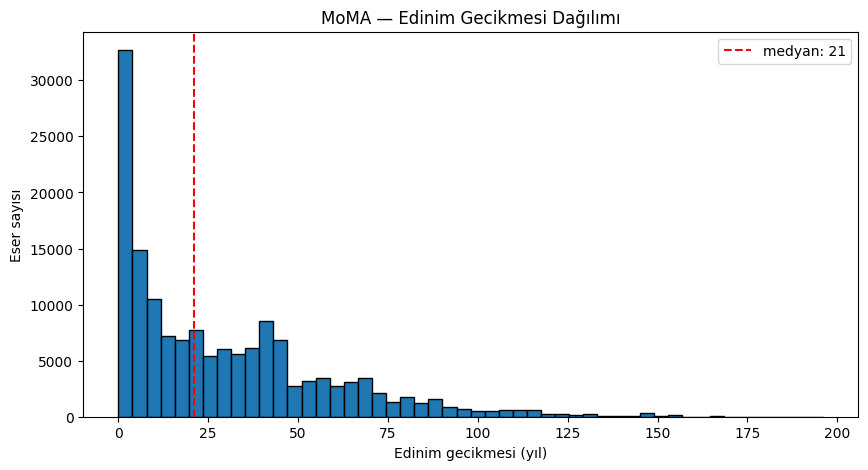

In [16]:
lag_computable = acquisition_lag[acquisition_lag["lag_status"] == "computable"].copy()

print(f"Computable share: {len(lag_computable):,} of {len(acquisition_lag):,} "
      f"({len(lag_computable) / len(acquisition_lag):.1%})\n")
print(lag_computable["acquisition_lag"].describe())

median_lag = lag_computable["acquisition_lag"].median()

plt.figure(figsize=(10, 5))
plt.hist(lag_computable["acquisition_lag"], bins=50, edgecolor="black", color="steelblue")
plt.axvline(median_lag, color="red", linestyle="--", label=f"median: {median_lag:.0f} years")
plt.xlabel("Acquisition lag (years)")
plt.ylabel("Number of artworks")
plt.title("MoMA — Distribution of Acquisition Lag")
plt.legend()
plt.show()

**The distribution is strongly right-skewed** — mean 29 years against a median of 21, with a
maximum of 196. A handful of very old works pull the mean up.

That single fact dictates the statistical method for the rest of the notebook: **the median
is reported throughout, and group comparisons use the Mann-Whitney U test** rather than a
*t*-test, because the normality assumption a *t*-test needs plainly does not hold here.

    edinim_on_yili   ortalama  medyan  eser_sayisi
0             1920   9.000000     9.0            9
1             1930  13.466370     8.0         1799
2             1940  17.954166    12.0         7418
3             1950  20.815360    12.0         6315
4             1960  28.180435    22.0        43107
5             1970  22.171335     7.0        13459
6             1980  27.945161     8.0        10157
7             1990  24.050749    10.0        11547
8             2000  30.901999    27.0        23959
9             2010  39.210713    38.0        25034
10            2020  41.354816    47.0         8348


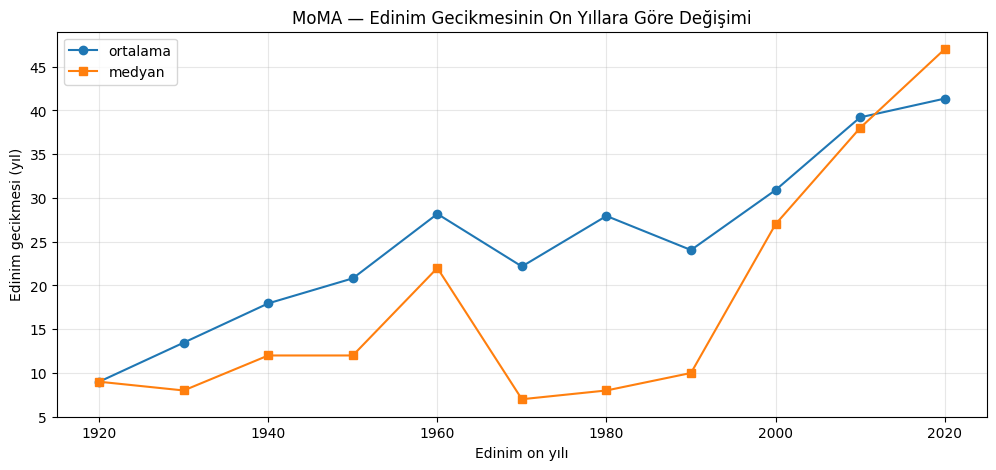

In [17]:
lag_computable["acquisition_decade"] = (lag_computable["acquired_year"] // 10) * 10

decade_summary = (
    lag_computable.groupby("acquisition_decade")["acquisition_lag"]
    .agg(mean="mean", median="median", artwork_count="count")
    .reset_index()
)
print(decade_summary)

plt.figure(figsize=(12, 5))
plt.plot(decade_summary["acquisition_decade"], decade_summary["mean"], marker="o", label="mean")
plt.plot(decade_summary["acquisition_decade"], decade_summary["median"], marker="s", label="median")
plt.xlabel("Acquisition decade")
plt.ylabel("Acquisition lag (years)")
plt.title("MoMA — Acquisition Lag by Decade")
plt.legend()
plt.show()

### Reading the baseline

**1960 is a spike, not a trend.** Both the median (22 years) and the volume (43,107 works —
several times any other decade) peak there. Section 10 shows this is two individual mass
donations rather than a shift in behaviour, and quantifies what happens when they are removed.

**1970–1990: MoMA collecting at the frontier.** The median sits at 7–10 years and barely
moves. The museum is buying recent, not-yet-canonised contemporary work.

**After 2000: an unbroken climb.** Median lag goes 10 (1990) → 27 (2000) → 38 (2010) →
47 (2020) — roughly six times the 1970s figure, rising monotonically.

**What it suggests.** The institution looks to have shifted from *tracking* contemporary art
to *canonising* it — acquiring work that already has a settled reputation. That is the
project's title question, and this curve is the first evidence for it. H4 (Section 12) tests
whether the shift is a consistent trajectory or noise.

> **Caveat.** The 2020 row covers a partial decade and rests on far fewer works than the
> others. It is directionally consistent with the trend but should not be read as a settled
> value.

---

# 7. H1 — Gender

> **Hypothesis.** Works by women artists entered the collection more slowly than works by men.

Two separate questions, often conflated, are kept apart here:

1. **Representation** — how many works, and how has that changed?
2. **Speed** — conditional on being collected, how long was the wait?

They have different answers, and the section below shows why the naive version of question 2
gives a badly wrong one.

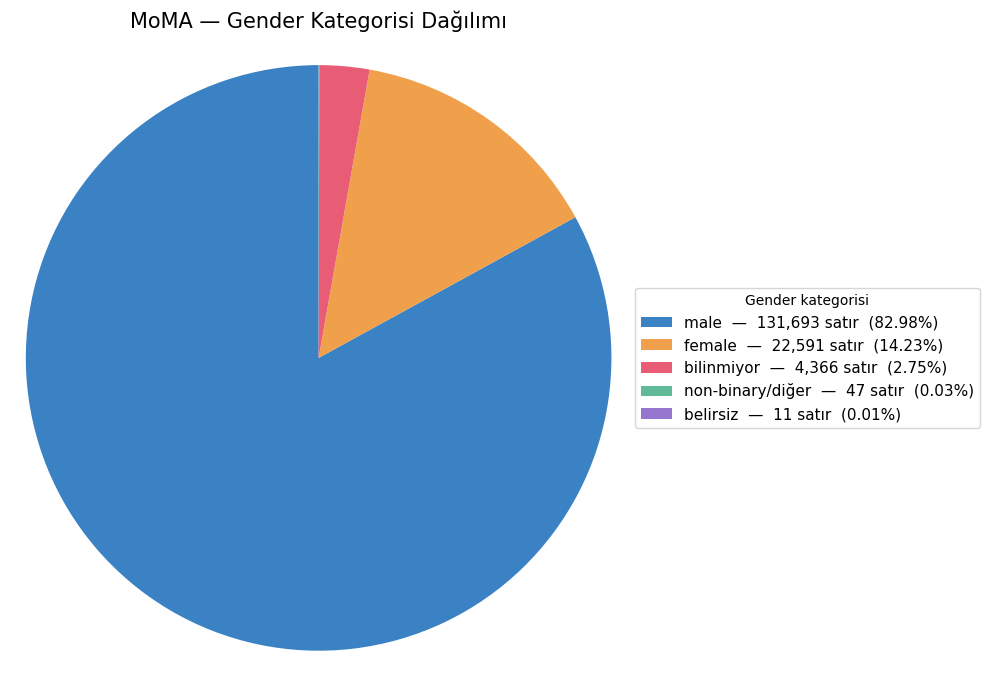

In [18]:
gender_counts = gender_analysis["gender_category"].value_counts()
gender_pct = (gender_counts / gender_counts.sum() * 100).round(2)

colors = ["#3B82C4", "#F0A04B", "#E85D75", "#5FBB97", "#9575CD"]

fig, ax = plt.subplots(figsize=(10, 7))
wedges, _ = ax.pie(gender_counts, startangle=90, colors=colors)

ax.legend(
    wedges,
    [f"{label}  —  {count:,} rows  ({pct}%)"
     for label, count, pct in zip(gender_counts.index, gender_counts.values, gender_pct)],
    title="Gender category",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
)
ax.set_title("MoMA — Gender Category Distribution (artwork-artist rows)", fontsize=14)
ax.axis("equal")
plt.tight_layout()
plt.show()

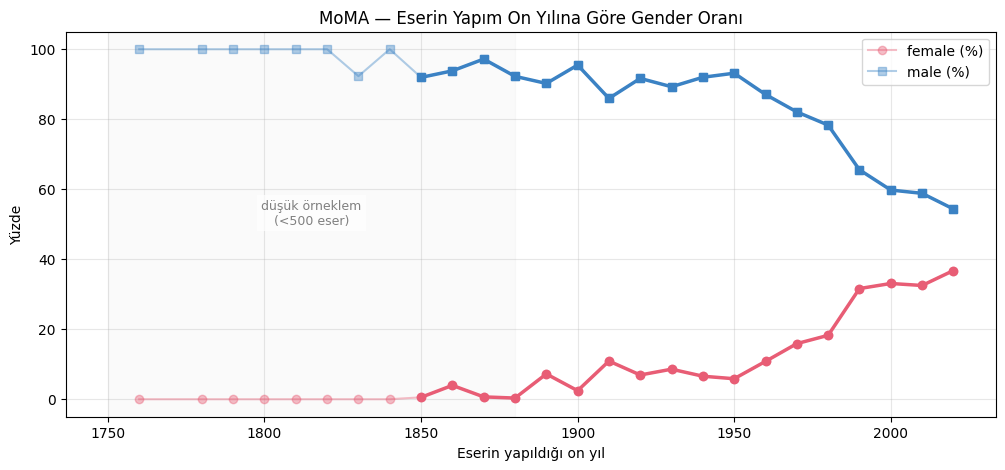

In [19]:
gender_df = gender_analysis.copy()
gender_df["acquisition_decade"] = (gender_df["acquired_year"] // 10) * 10

# Share of works by creation decade
creation_decade_counts = gender_df.groupby("creation_decade").size()
gender_by_creation = (
    gender_df.groupby(["creation_decade", "gender_category"]).size().unstack(fill_value=0)
)
gender_by_creation_pct = gender_by_creation.div(gender_by_creation.sum(axis=1), axis=0) * 100

# Pre-1880 decades hold only a handful of works, so their percentages are noise,
# not signal. Draw them faintly and shade the region rather than dropping them.
RELIABLE_THRESHOLD = 500
reliable_decades = creation_decade_counts[creation_decade_counts >= RELIABLE_THRESHOLD].index
reliable_pct = gender_by_creation_pct.loc[gender_by_creation_pct.index.isin(reliable_decades)]

plt.figure(figsize=(12, 5))
plt.plot(gender_by_creation_pct.index, gender_by_creation_pct["female"],
         marker="o", color=FEMALE_C, label="female (%)", alpha=0.4)
plt.plot(gender_by_creation_pct.index, gender_by_creation_pct["male"],
         marker="s", color=MALE_C, label="male (%)", alpha=0.4)
plt.plot(reliable_pct.index, reliable_pct["female"], marker="o", color=FEMALE_C, linewidth=2.5)
plt.plot(reliable_pct.index, reliable_pct["male"], marker="s", color=MALE_C, linewidth=2.5)

plt.axvspan(1750, 1880, alpha=0.04, color="gray")
plt.text(1815, 50, f"small sample\n(<{RELIABLE_THRESHOLD} works)", fontsize=9,
         ha="center", color="gray",
         bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=3))

plt.xlabel("Decade the work was created")
plt.ylabel("Share (%)")
plt.title("MoMA — Gender Share by Creation Decade")
plt.legend()
plt.show()

### Representation is improving, and is not yet equal

Before 1880 the sample is tiny — some decades hold single-digit numbers of works — so the
0%/100% swings there are statistical noise, not evidence of anything. That region is shaded
and drawn faintly rather than deleted, so the reader can see *why* it is being discounted.

From 1890 on (2,631+ works per decade) the trend is clean: **the share of works by women
rises from 16.2% in 1970 to 40.3% in 2020**, accelerating after 1970.

40% is not 50%. "Approaching parity" is the accurate description; "reached parity" is not.

> **Outside knowledge, flagged as such.** Art history offers plausible mechanisms for the
> historical baseline — women's work being attributed to a husband or father, for instance.
> That is context from the literature, **not** something observed in this dataset, and it is
> marked here so the two are not confused.

edinim_on_yili
1920        9
1930     1786
1940     7375
1950     6507
1960    43868
1970    13612
1980    10712
1990    12275
2000    25662
2010    27779
2020     9123
dtype: int64


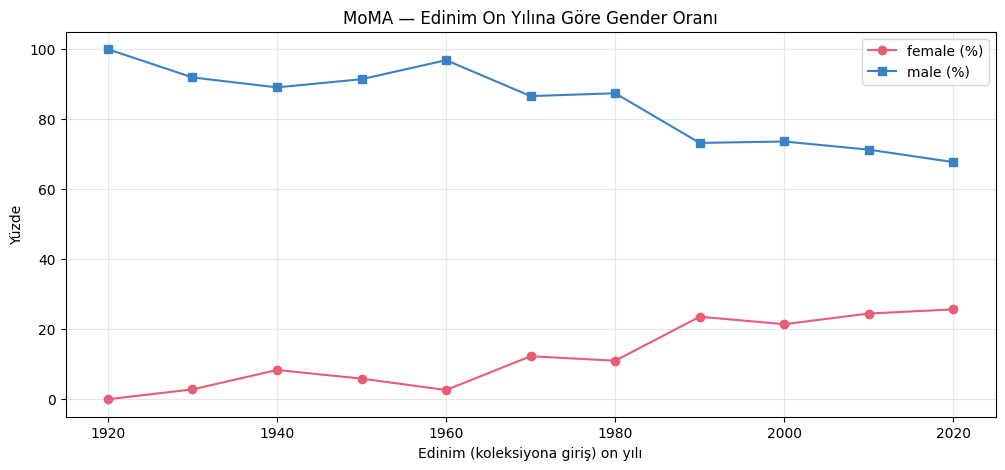

In [20]:
acq_decade_counts = gender_df.groupby("acquisition_decade").size()
gender_by_acq = (
    gender_df.groupby(["acquisition_decade", "gender_category"]).size().unstack(fill_value=0)
)
gender_by_acq_pct = gender_by_acq.div(gender_by_acq.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 5))
plt.plot(gender_by_acq_pct.index, gender_by_acq_pct["female"],
         marker="o", color=FEMALE_C, label="female (%)")
plt.plot(gender_by_acq_pct.index, gender_by_acq_pct["male"],
         marker="s", color=MALE_C, label="male (%)")
plt.xlabel("Decade the work entered the collection")
plt.ylabel("Share (%)")
plt.title("MoMA — Gender Share by Acquisition Decade")
plt.legend()
plt.show()

## 7.1 The confounder — and why the naive answer is wrong

This is the most important methodological step in the project.

In [21]:
binary = gender_analysis[gender_analysis["gender_category"].isin(["male", "female"])]

print("Raw acquisition lag by gender:")
print(binary.groupby("gender_category")["acquisition_lag"].agg(
    mean="mean", median="median", n="count"))

print("\nCreation year by gender:")
print(binary.groupby("gender_category")["extracted_year"].agg(mean="mean", median="median"))

                  ortalama  medyan  sayisi
gender_kategori                           
female           22.736178    11.0   22591
male             29.099155    22.0  131693


### Read those two tables together

The first table says works by women are acquired **faster** — mean 22.7 years against 29.1
for men. Taken alone, that reads as MoMA favouring women artists.

The second table shows why that is an artefact. **Works by women in this collection are on
average 23 years more recent** (mean creation year 1978 vs 1955). Because the share of women
only rises meaningfully after 1970, their works have had far less calendar time in which to
*accumulate* lag. A work made in 2015 cannot have a 40-year lag yet.

The apparent advantage is **creation year masquerading as gender**. The fix is to hold
creation year fixed and compare within periods.

In [22]:
def compare_window(df, group_col, groups, start, end, label=None):
    # Compare lag between groups for works created in a fixed window, so creation
    # year cannot drive the difference.
    window = df[(df["extracted_year"] >= start) & (df["extracted_year"] <= end)]
    result = (
        window[window[group_col].isin(groups)]
        .groupby(group_col)
        .agg(mean_creation_year=("extracted_year", "mean"),
             mean_lag=("acquisition_lag", "mean"),
             median_lag=("acquisition_lag", "median"),
             artwork_count=("object_id", "nunique"))
    )
    print(f"\n--- {label or f'{start}-{end}'} ---")
    print(result)
    return result


PERIODS = [(1950, 1970), (1970, 1990), (1990, 2010)]

h1_periods = {
    f"{s}-{e}": compare_window(gender_analysis, "gender_category", ["female", "male"], s, e)
    for s, e in PERIODS
}


--- 1950-1970 arası ---
                 ortalama_uretim_yili  ortalama_gecikme  medyan_gecikme  \
gender_kategori                                                           
female                    1963.120323         30.220458            39.0   
male                      1961.511782         20.971273            11.0   

                 eser_sayisi  
gender_kategori               
female                  3612  
male                   35237  

--- 1970-1990 arası ---
                 ortalama_uretim_yili  ortalama_gecikme  medyan_gecikme  \
gender_kategori                                                           
female                    1979.646996         23.224282            27.0   
male                      1977.824153         20.004310            18.0   

                 eser_sayisi  
gender_kategori               
female                  5347  
male                   23250  

--- 1990-2010 arası ---
                 ortalama_uretim_yili  ortalama_gecikme  medyan_gecikme  \


### H1 result: the gap was real, and it closed

With creation year held fixed, the picture inverts — and the true pattern appears.

| Period created | Median lag, women | Median lag, men | Gap |
|---|---|---|---|
| 1950–1970 | 39 years | 11 years | **+28** |
| 1970–1990 | 27 years | 18 years | **+9** |
| 1990–2010 | 5 years | 5 years | **0** |

Works by women created in the 1950s and 60s waited roughly **three and a half times longer**
for MoMA to acquire them. That gap narrows steadily and is gone by the 1990–2010 cohort.

Section 11 tests whether these differences are statistically significant — including whether
that final zero is a real convergence or just a smaller sample.

**H1 verdict: supported for the historical period, closed in the contemporary one.** MoMA's
improvement on gender has been *behavioural*, not merely numerical — it is not only
collecting more women, it stopped making them wait longer.

---

# 8. H2 — Geography

> **Hypothesis.** Works by non-Western artists entered the collection more slowly, and the
> gap is narrowing.

Same structure as H1: representation first, then speed, then the confounder check. The
result is different in a way that turns out to be the project's central finding.

ulke_bolge
United States     76515
France            24593
Germany            9820
United Kingdom     6991
Italy              3667
Russia             3635
Spain              3466
Japan              2930
Switzerland        2596
Netherlands        2073
Argentina          2058
Mexico             1809
Belgium            1532
Unknown            1328
Austria            1241
Name: count, dtype: int64


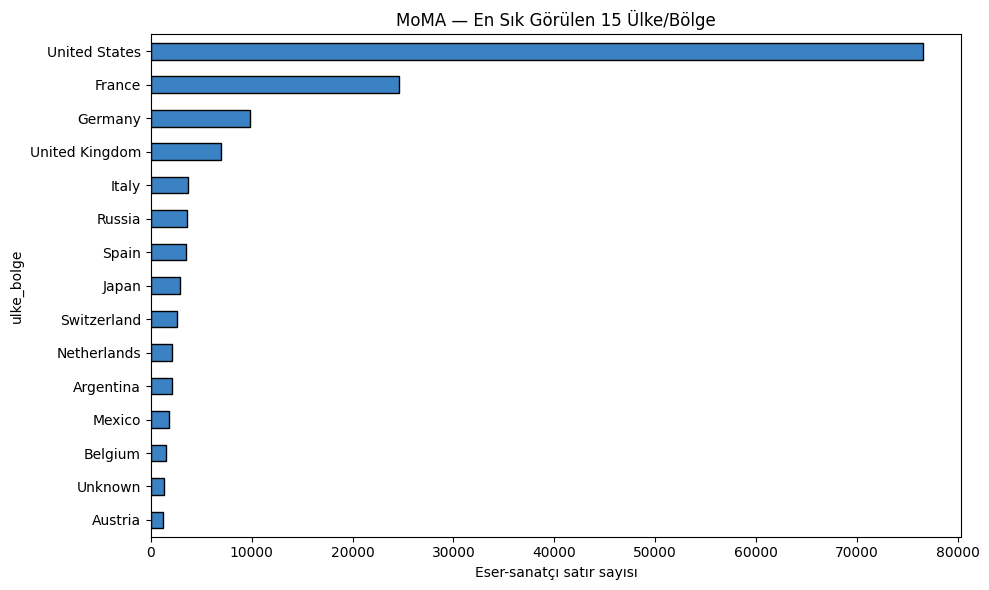

In [23]:
top_countries = geography_analysis["country_region"].value_counts().head(15)
print(top_countries)

plt.figure(figsize=(10, 6))
top_countries.plot(kind="barh", color=MALE_C, edgecolor="black")
plt.xlabel("Artwork-artist rows")
plt.title("MoMA — 15 Most Represented Countries / Regions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8.1 Defining "Western"

Any West / non-West split is a simplification of a genuinely contested concept, so the
definition is written out explicitly rather than left implicit in a regex.

**Western** here means Western and Northern Europe plus North America — the geography MoMA's
founding collection was drawn from. Everything else, including Latin America, Eastern Europe,
Asia and Africa, is **non-Western**. Artists whose nationality could not be mapped are kept
as a third `Unknown` category and excluded from the comparisons rather than being folded into
either side.

This is a blunt instrument, and it is the right resolution for the question being asked —
whether the museum's collecting followed its own cultural centre of gravity — but it should
not be read as a claim about individual artists' identities.

In [24]:
WESTERN_COUNTRIES = [
    "United States", "France", "Germany", "United Kingdom", "Italy",
    "Spain", "Switzerland", "Netherlands", "Belgium", "Austria",
    "Canada", "Denmark", "Sweden", "Norway", "Finland", "Ireland",
    "Portugal", "Luxembourg", "Iceland",
]


def west_category(country):
    if country in WESTERN_COUNTRIES:
        return "Western"
    return "Unknown" if country == "Unknown" else "Non-Western"


geography_analysis["west_category"] = geography_analysis["country_region"].apply(west_category)

print(geography_analysis["west_category"].value_counts())
print()
print((geography_analysis["west_category"].value_counts(normalize=True) * 100).round(1))

bati_kategori
Batı          135322
Batı-dışı      22058
Bilinmiyor      1328
Name: count, dtype: int64
bati_kategori
Batı          85.3
Batı-dışı     13.9
Bilinmiyor     0.8
Name: proportion, dtype: float64


yapim_on_yili
1760.0        5
1780.0        1
1790.0       81
1800.0        4
1810.0      425
1820.0       22
1830.0       13
1840.0      304
1850.0      732
1860.0     1214
1870.0      747
1880.0      607
1890.0     2624
1900.0     4451
1910.0     7487
1920.0    12151
1930.0    12376
1940.0    14651
1950.0    14382
1960.0    24567
1970.0    19405
1980.0    11651
1990.0    11227
2000.0    11552
2010.0     5518
2020.0     1183
dtype: int64


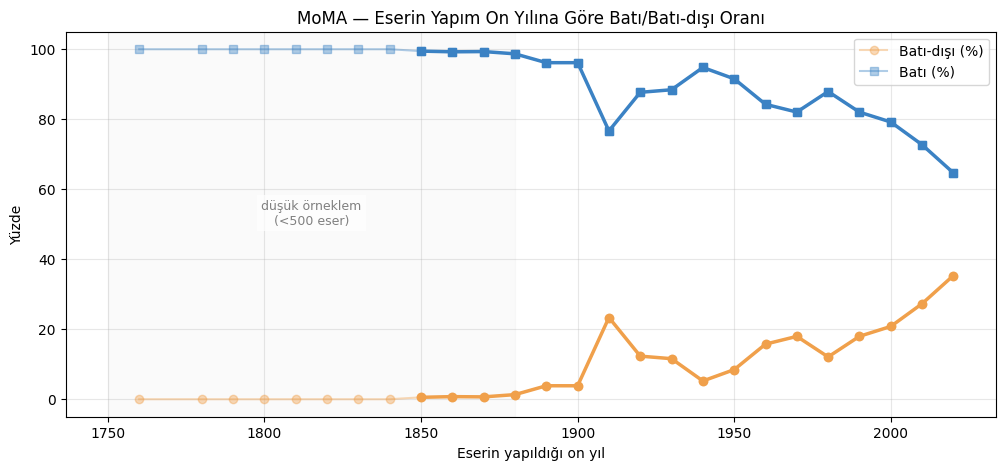

In [25]:
geography_df = geography_analysis[
    geography_analysis["west_category"].isin(["Western", "Non-Western"])
].copy()
geography_df["acquisition_decade"] = (geography_df["acquired_year"] // 10) * 10

creation_counts_geo = geography_df.groupby("creation_decade").size()
west_by_creation = (
    geography_df.groupby(["creation_decade", "west_category"]).size().unstack(fill_value=0)
)
west_by_creation_pct = west_by_creation.div(west_by_creation.sum(axis=1), axis=0) * 100

reliable_decades_geo = creation_counts_geo[creation_counts_geo >= RELIABLE_THRESHOLD].index
reliable_pct_geo = west_by_creation_pct.loc[
    west_by_creation_pct.index.isin(reliable_decades_geo)
]

plt.figure(figsize=(12, 5))
plt.plot(west_by_creation_pct.index, west_by_creation_pct["Non-Western"],
         marker="o", color=NONWEST_C, label="Non-Western (%)", alpha=0.4)
plt.plot(west_by_creation_pct.index, west_by_creation_pct["Western"],
         marker="s", color=WEST_C, label="Western (%)", alpha=0.4)
plt.plot(reliable_pct_geo.index, reliable_pct_geo["Non-Western"],
         marker="o", color=NONWEST_C, linewidth=2.5)
plt.plot(reliable_pct_geo.index, reliable_pct_geo["Western"],
         marker="s", color=WEST_C, linewidth=2.5)

plt.axvspan(1750, 1880, alpha=0.04, color="gray")
plt.text(1815, 50, f"small sample\n(<{RELIABLE_THRESHOLD} works)", fontsize=9,
         ha="center", color="gray",
         bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=3))

plt.xlabel("Decade the work was created")
plt.ylabel("Share (%)")
plt.title("MoMA — Western / Non-Western Share by Creation Decade")
plt.legend()
plt.show()

edinim_on_yili
1920        9
1930     1781
1940     7353
1950     6423
1960    43816
1970    13555
1980    10698
1990    12180
2000    25216
2010    27297
2020     9052
dtype: int64


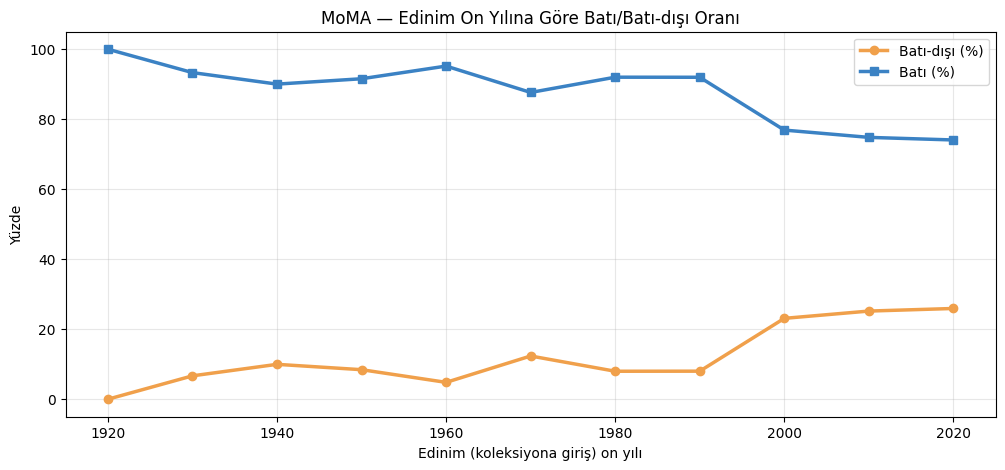

In [26]:
west_by_acq = (
    geography_df.groupby(["acquisition_decade", "west_category"]).size().unstack(fill_value=0)
)
west_by_acq_pct = west_by_acq.div(west_by_acq.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 5))
plt.plot(west_by_acq_pct.index, west_by_acq_pct["Non-Western"],
         marker="o", color=NONWEST_C, label="Non-Western (%)", linewidth=2.5)
plt.plot(west_by_acq_pct.index, west_by_acq_pct["Western"],
         marker="s", color=WEST_C, label="Western (%)", linewidth=2.5)
plt.xlabel("Decade the work entered the collection")
plt.ylabel("Share (%)")
plt.title("MoMA — Western / Non-Western Share by Acquisition Decade")
plt.legend()
plt.show()

In [27]:
binary_geo = geography_analysis[
    geography_analysis["west_category"].isin(["Western", "Non-Western"])
]

print("Raw acquisition lag by origin:")
print(binary_geo.groupby("west_category")["acquisition_lag"].agg(
    mean="mean", median="median", n="count"))

print("\nCreation year by origin:")
print(binary_geo.groupby("west_category")["extracted_year"].agg(mean="mean", median="median"))

                ortalama  medyan  sayisi
bati_kategori                           
Batı           27.736281    20.0  135322
Batı-dışı      30.746804    26.0   22058
                  ortalama  medyan
bati_kategori                     
Batı           1956.572405  1961.0
Batı-dışı      1968.017726  1970.0


### The same confounder check, a different outcome

Raw lag runs against non-Western artists — mean 30.7 years vs 27.7 — the opposite direction
to the raw gender result.

The creation-year gap here is only **9 years** (1968 vs 1957), against 23 years for gender.
That is small enough that it cannot explain a 3-year lag difference on its own, but too large
to dismiss. A simple mean comparison cannot separate the two effects, so the same
period-controlled comparison is needed.

In [28]:
h2_periods = {
    f"{s}-{e}": compare_window(
        geography_analysis, "west_category", ["Western", "Non-Western"], s, e)
    for s, e in PERIODS
}


--- 1950-1970 arası ---
               ortalama_uretim_yili  ortalama_gecikme  medyan_gecikme  \
bati_kategori                                                           
Batı                    1961.433524         20.943008            11.0   
Batı-dışı               1963.250410         28.495720            39.0   

               eser_sayisi  
bati_kategori               
Batı                 34034  
Batı-dışı             4887  

--- 1970-1990 arası ---
               ortalama_uretim_yili  ortalama_gecikme  medyan_gecikme  \
bati_kategori                                                           
Batı                    1978.361237         19.229955            15.0   
Batı-dışı               1977.260684         27.464258            33.0   

               eser_sayisi  
bati_kategori               
Batı                 24678  
Batı-dışı             4350  

--- 1990-2010 arası ---
               ortalama_uretim_yili  ortalama_gecikme  medyan_gecikme  \
bati_kategori                     

### H2 result: the gap is real, persistent, and narrowing but not closed

| Period created | Median lag, non-Western | Median lag, Western | Gap |
|---|---|---|---|
| 1950–1970 | 39 years | 11 years | **+28** |
| 1970–1990 | 33 years | 15 years | **+18** |
| 1990–2010 | 9 years | 4 years | **+5** |

Within each window the two groups' mean creation years are **almost identical** — chronology
is controlled for, and the difference survives.

Non-Western works wait **two to three times longer** in every period. The gap narrows from
28 years to 5, but unlike H1 it never reaches zero.

**H1 vs H2 is the finding.** Same museum, same metric, same method — and one disparity
resolves completely while the other persists across seventy years. Gender was addressed;
geography was mitigated. Section 11 confirms that both the persistence and the H1 convergence
hold up statistically.

---

# 9. H3 — Movements

> **Hypothesis.** MoMA recognised some movements early and others late, and that timing
> relates to how heavily it collected them.

**Coverage constraint, stated up front.** Movement data comes from Wikidata and exists for
only **69,755 works — 43.4% of the collection**. Every number in this section is computed on
that subset. Where a percentage could be misread, both denominators are shown.

Because the movement bridge is one-to-many, everything here counts **distinct `object_id`**,
never rows. A Picasso work tagged with three movements would otherwise be counted three
times.

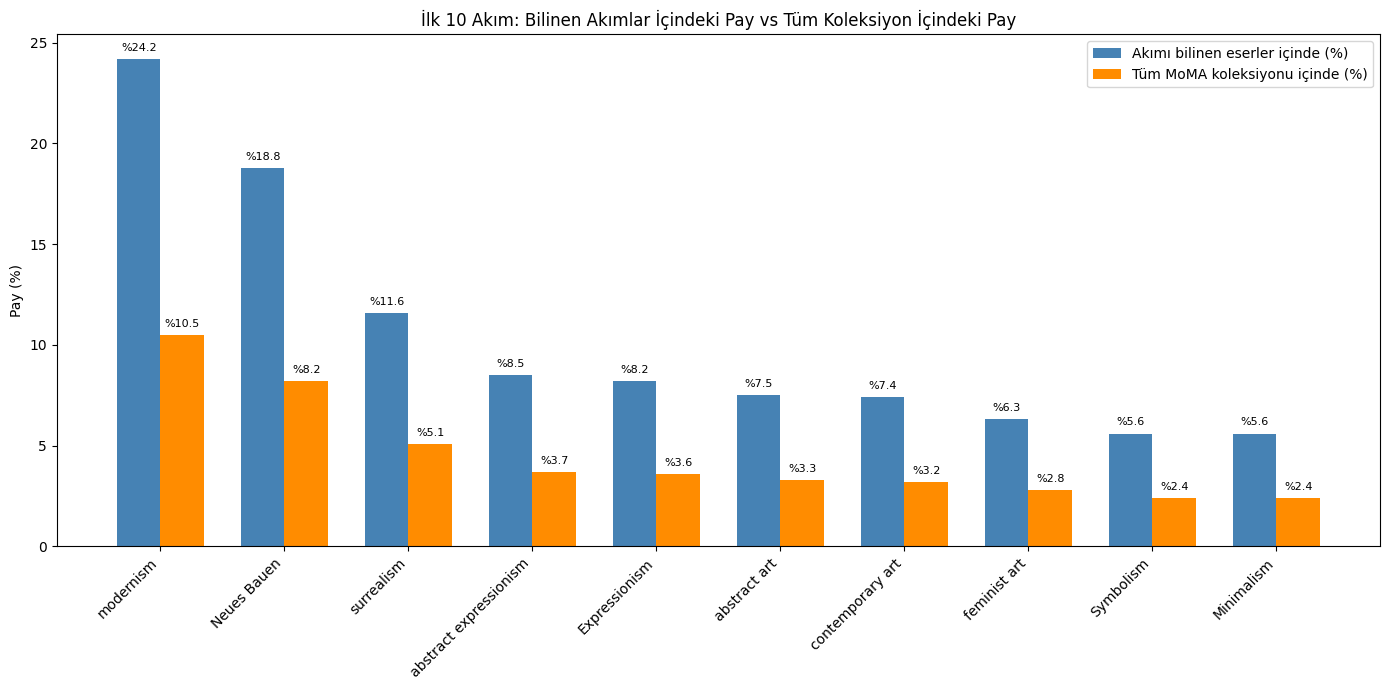

Toplam MoMA eseri: 160,705
Akımı bilinen eser: 69,755 (%43.4)

                        eser_sayısı  yüzde_bilinen_içinde  yüzde_toplam_içinde
movement                                                                      
modernism                     16854                  24.2                 10.5
Neues Bauen                   13136                  18.8                  8.2
surrealism                     8119                  11.6                  5.1
abstract expressionism         5920                   8.5                  3.7
Expressionism                  5715                   8.2                  3.6
abstract art                   5255                   7.5                  3.3
contemporary art               5142                   7.4                  3.2
feminist art                   4429                   6.3                  2.8
Symbolism                      3899                   5.6                  2.4
Minimalism                     3891                   5.6           

In [29]:
# Count DISTINCT artworks per movement — a work tagged with three movements
# must not count three times.
movement_artwork_counts = (
    movement_analysis.groupby("movement")["object_id"].nunique().sort_values(ascending=False)
)
top10_movements = movement_artwork_counts.head(10)
top10_list = top10_movements.index.tolist()

artworks_with_movement = movement_analysis["object_id"].nunique()
total_artworks = acquisition_lag["object_id"].nunique()

# Two denominators, because they tell different stories:
#   A) share of the movement-tagged subset
#   B) share of the entire collection
pct_of_known = (top10_movements / artworks_with_movement * 100).round(1)
pct_of_total = (top10_movements / total_artworks * 100).round(1)

x = np.arange(len(top10_movements))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width / 2, pct_of_known.values, width,
               label="Share of movement-tagged works (%)", color="steelblue")
bars2 = ax.bar(x + width / 2, pct_of_total.values, width,
               label="Share of entire collection (%)", color="darkorange")

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{bar.get_height()}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(top10_movements.index, rotation=45, ha="right")
ax.set_ylabel("Share (%)")
ax.set_title("Top 10 Movements: Share of Tagged Subset vs Entire Collection")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total MoMA artworks:          {total_artworks:,}")
print(f"With a movement tag:          {artworks_with_movement:,} "
      f"({artworks_with_movement / total_artworks:.1%})")
print()
print(pd.DataFrame({"artworks": top10_movements,
                    "pct_of_tagged": pct_of_known,
                    "pct_of_collection": pct_of_total}))

Every one of the top 10 is a late-19th or 20th-century movement — exactly what a museum
founded in 1929 to collect *modern* art should look like. The collection is consistent with
its own mandate, which is a useful sanity check that the enrichment join is sound.

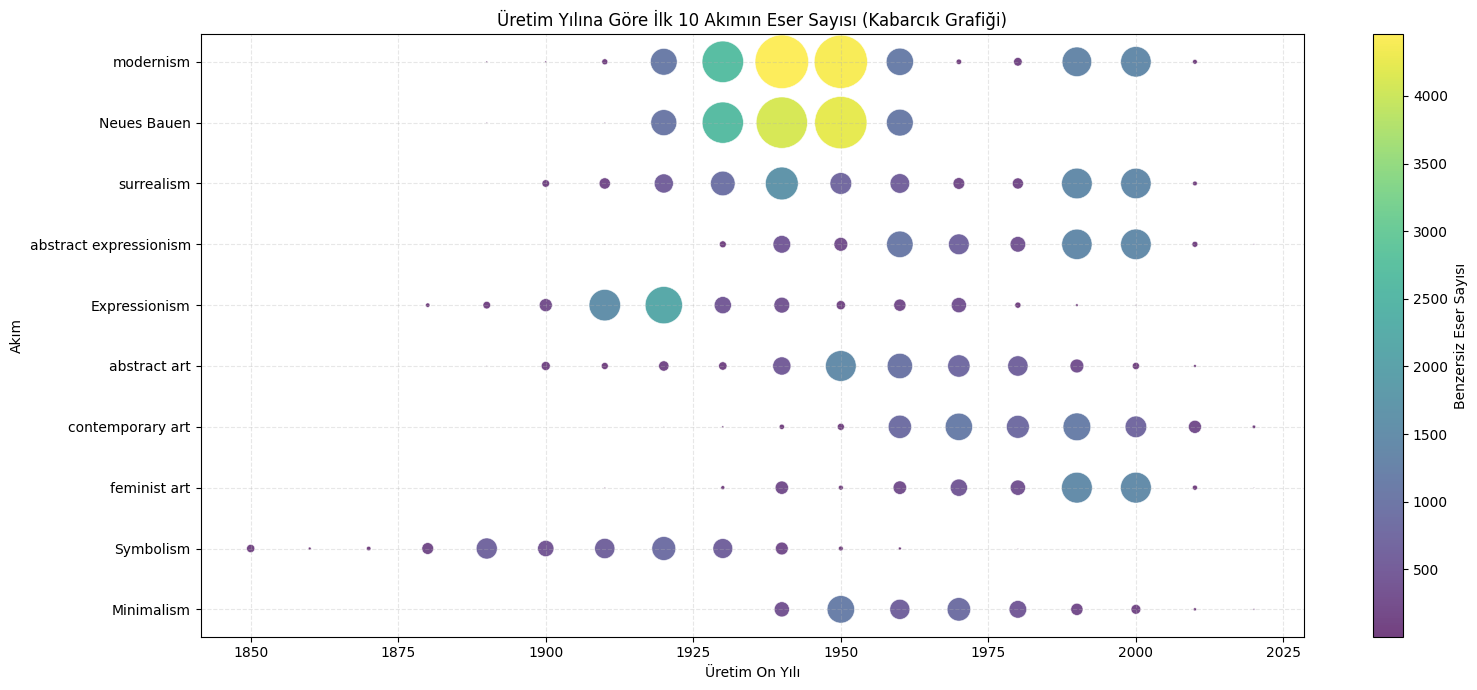

In [30]:
# Creation timing: when were these movements' works actually made?
creation_pivot = (
    movement_analysis[movement_analysis["movement"].isin(top10_list)]
    .groupby(["movement", "creation_decade"])["object_id"]
    .nunique()
    .unstack(fill_value=0)
    .loc[top10_list]
)

creation_long = (
    creation_pivot.reset_index()
    .melt(id_vars="movement", var_name="creation_decade", value_name="artwork_count")
)
creation_long = creation_long[creation_long["artwork_count"] > 0]

# Map movement -> y position so the two bubble charts share an identical axis
# and can be compared directly.
movement_to_pos = {mov: i for i, mov in enumerate(top10_list)}
creation_long["y_pos"] = creation_long["movement"].map(movement_to_pos)

fig, ax = plt.subplots(figsize=(16, 7))
scatter = ax.scatter(
    creation_long["creation_decade"], creation_long["y_pos"],
    s=creation_long["artwork_count"] / 3, c=creation_long["artwork_count"],
    cmap="viridis", alpha=0.75, edgecolors="white", linewidth=0.5,
)
ax.set_yticks(range(len(top10_list)))
ax.set_yticklabels(top10_list)
ax.invert_yaxis()
ax.set_title("When the Works Were MADE — Top 10 Movements by Creation Decade")
ax.set_xlabel("Creation decade")
ax.set_ylabel("Movement")
plt.colorbar(scatter, ax=ax).set_label("Distinct artworks")
plt.tight_layout()
plt.show()

Edinim Yılına Göre (On Yıllık) Benzersiz Eser Sayısı:
edinim_on_yili          1920  1930  1940  1950   1960  1970  1980  1990  2000  \
movement                                                                        
modernism                  0    11    88    80  12464   819    44   965  1476   
Neues Bauen                0     1    19     9  12237   799    22     6    32   
surrealism                 0   123   506   531   2136   399   245  1252  1549   
abstract expressionism     0     1    45   107    741   795   494  1138  1565   
Expressionism              9   283  1041   928   2448   502   203    70    67   
abstract art               0    21    55   146    760   517   252   461   541   
contemporary art           0     2     6    14    457   420   365  1025   958   
feminist art               0     0    10     2     29    35   129  1190  1605   
Symbolism                  0    39   362   336   2734   137    28    18   176   
Minimalism                 0     0     0     1    115  

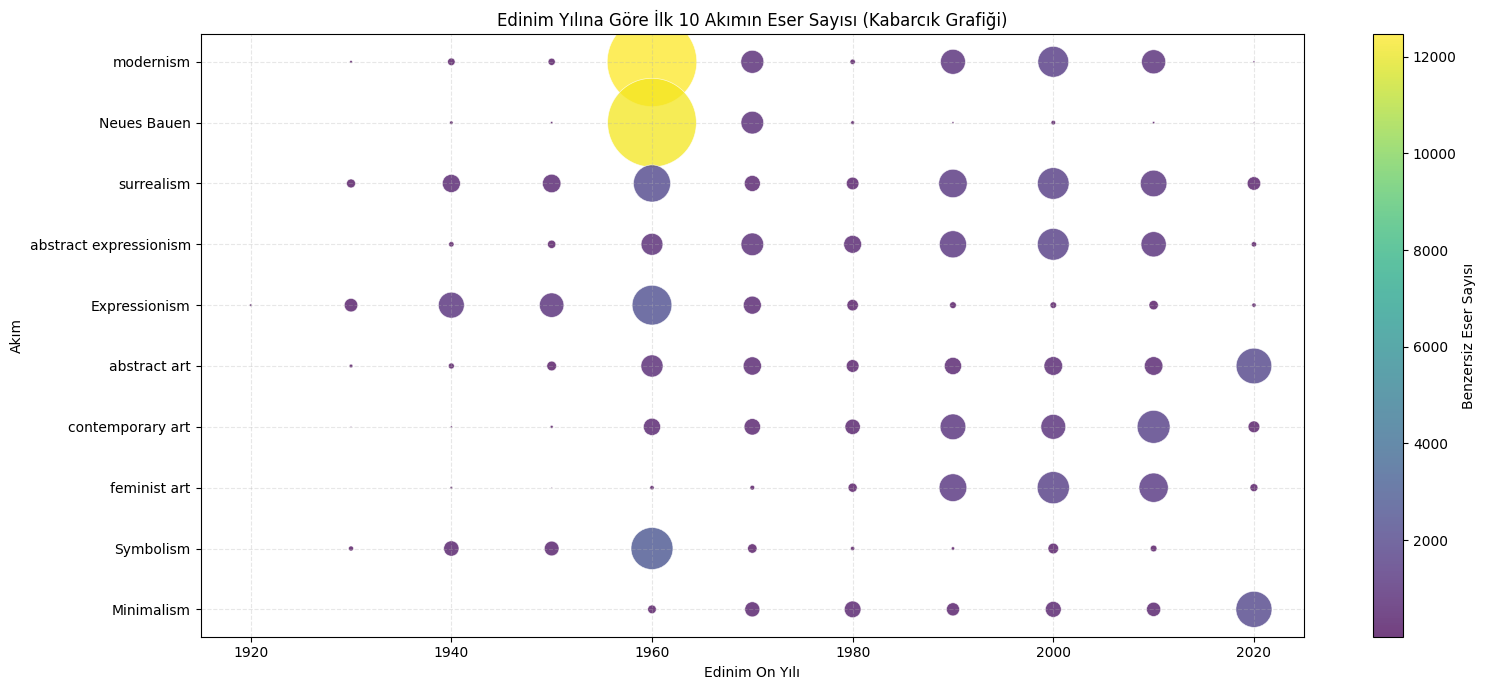

In [31]:
# Acquisition timing: when did MoMA actually buy them?
movement_analysis["acquisition_decade"] = (movement_analysis["acquired_year"] // 10) * 10

acquisition_pivot = (
    movement_analysis[movement_analysis["movement"].isin(top10_list)]
    .groupby(["movement", "acquisition_decade"])["object_id"]
    .nunique()
    .unstack(fill_value=0)
    .loc[top10_list]
)

acquisition_long = (
    acquisition_pivot.reset_index()
    .melt(id_vars="movement", var_name="acquisition_decade", value_name="artwork_count")
)
acquisition_long = acquisition_long[acquisition_long["artwork_count"] > 0]
acquisition_long["y_pos"] = acquisition_long["movement"].map(movement_to_pos)

fig, ax = plt.subplots(figsize=(16, 7))
scatter = ax.scatter(
    acquisition_long["acquisition_decade"], acquisition_long["y_pos"],
    s=acquisition_long["artwork_count"] / 3, c=acquisition_long["artwork_count"],
    cmap="viridis", alpha=0.75, edgecolors="white", linewidth=0.5,
)
ax.set_yticks(range(len(top10_list)))
ax.set_yticklabels(top10_list)
ax.invert_yaxis()
ax.set_title("When MoMA ACQUIRED Them — Top 10 Movements by Acquisition Decade")
ax.set_xlabel("Acquisition decade")
ax.set_ylabel("Movement")
plt.colorbar(scatter, ax=ax).set_label("Distinct artworks")
plt.tight_layout()
plt.show()

Comparing the two charts on the same axis shows the **phase shift** directly. Modernism and
Neues Bauen were produced in 1920–1940, but MoMA's bulk acquisition of them lands in
1950–1960 — consistent with a museum founded in 1929 that had to build its holdings
retrospectively.

In [32]:
# Sanity check before aggregating lag by movement: is the same object_id
# duplicated inside a single movement? If so, the mean would be weighted wrong.
dup_check = (
    movement_analysis[movement_analysis["movement"].isin(top10_list)]
    .groupby(["movement", "object_id"]).size()
)
print(f"(movement, object_id) pairs appearing more than once: {(dup_check > 1).sum()}")

lag_by_movement = (
    movement_analysis[movement_analysis["movement"].isin(top10_list)]
    .groupby(["movement", "object_id"])["acquisition_lag"]
    .first()
    .reset_index()
    .groupby("movement")["acquisition_lag"]
    .agg(["count", "mean", "median", "std"])
    .loc[top10_list]
)
print()
print(lag_by_movement)

                        count       mean  median        std
movement                                                   
modernism               16854  19.976860    18.0  12.902477
Neues Bauen             13136  22.340438    20.5  11.456442
surrealism               8119  19.556103    13.0  21.657921
abstract expressionism   5920  11.008953     6.0  13.793315
Expressionism            5715  33.216623    34.0  20.449481
abstract art             5255  36.675928    41.0  27.029771
contemporary art         5142  14.210035     4.0  16.638222
feminist art             4429  14.581170     8.0  15.703915
Symbolism                3899  49.868941    48.0  24.596998
Minimalism               3891  39.103829    44.0  27.250830


## 9.1 Adding historical reference points

The top 10 are all modern movements, which makes them poor at revealing a *trend* — they
barely span any range on the creation-year axis. To find the trend line, older movements are
needed as anchors.

Rather than picking them by intuition, candidates are selected by rule: the earliest mean
creation year among movements holding **at least 20 works**, so no anchor rests on a handful
of objects.

In [33]:
movements_by_year = (
    movement_analysis.groupby(["movement", "object_id"])
    .agg({"extracted_year": "first"})
    .reset_index()
    .groupby("movement")
    .agg(mean_creation_year=("extracted_year", "mean"),
         artwork_count=("object_id", "count"))
)

MIN_ANCHOR_SIZE = 20
oldest_candidates = (
    movements_by_year[movements_by_year["artwork_count"] >= MIN_ANCHOR_SIZE]
    .sort_values("mean_creation_year")
    .head(10)
)
print(oldest_candidates)

                            ortalama_uretim_yili  eser_sayisi
movement                                                     
Rococo                               1804.812155          181
Romanticism                          1823.140984          305
literary realism                     1848.560976           41
Golden Age of Illustration           1853.980583          103
Pre-Raphaelite Brotherhood           1892.467391           92
Art Nouveau                          1896.752551          392
Vienna Secession                     1899.575758           33
Japonisme                            1904.661017           59
pictorialism                         1911.840807          446
Orientalism                          1912.382924          773


/tmp/ipykernel_1543/20762066.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=order, showfliers=False)


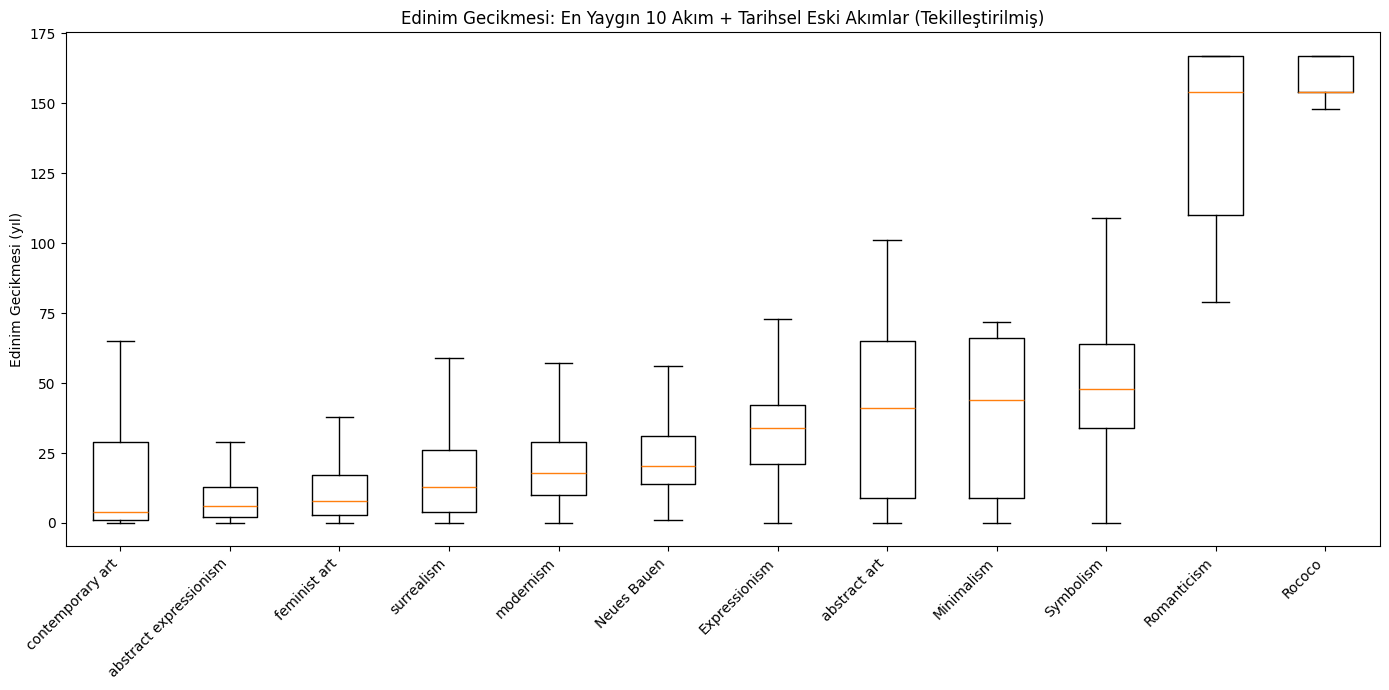

In [34]:
HISTORICAL_MOVEMENTS = ["Rococo", "Romanticism", "literary realism",
                        "Art Nouveau", "Orientalism"]
extended_movements = top10_list + HISTORICAL_MOVEMENTS

extended_df = movement_analysis[movement_analysis["movement"].isin(extended_movements)]

# Deduplicate to one row per (movement, artwork) before any lag aggregation.
lag_dedup_extended = (
    extended_df.groupby(["movement", "object_id"])["acquisition_lag"].first().reset_index()
)

order = lag_dedup_extended.groupby("movement")["acquisition_lag"].median().sort_values().index
data_to_plot = [
    lag_dedup_extended.loc[lag_dedup_extended["movement"] == m, "acquisition_lag"].values
    for m in order
]

fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(data_to_plot, showfliers=False)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_title("Acquisition Lag by Movement — Top 10 plus Historical Anchors")
ax.set_ylabel("Acquisition lag (years)")
plt.tight_layout()
plt.show()

## 9.2 Residual analysis — early or late relative to expectation?

Raw lag cannot be compared across movements, because older movements mechanically have
longer lags. A Rococo work has had 250 years to be acquired; a Minimalist work has had 60.

So a baseline is fitted first: a linear trend of **mean lag on mean creation year** across
all 15 movements. The **residual** — actual lag minus what the trend predicts for a movement
of that vintage — is the age-adjusted measure.

- **Negative residual** → MoMA recognised this movement **earlier** than its era would predict
- **Positive residual** → recognised **later**

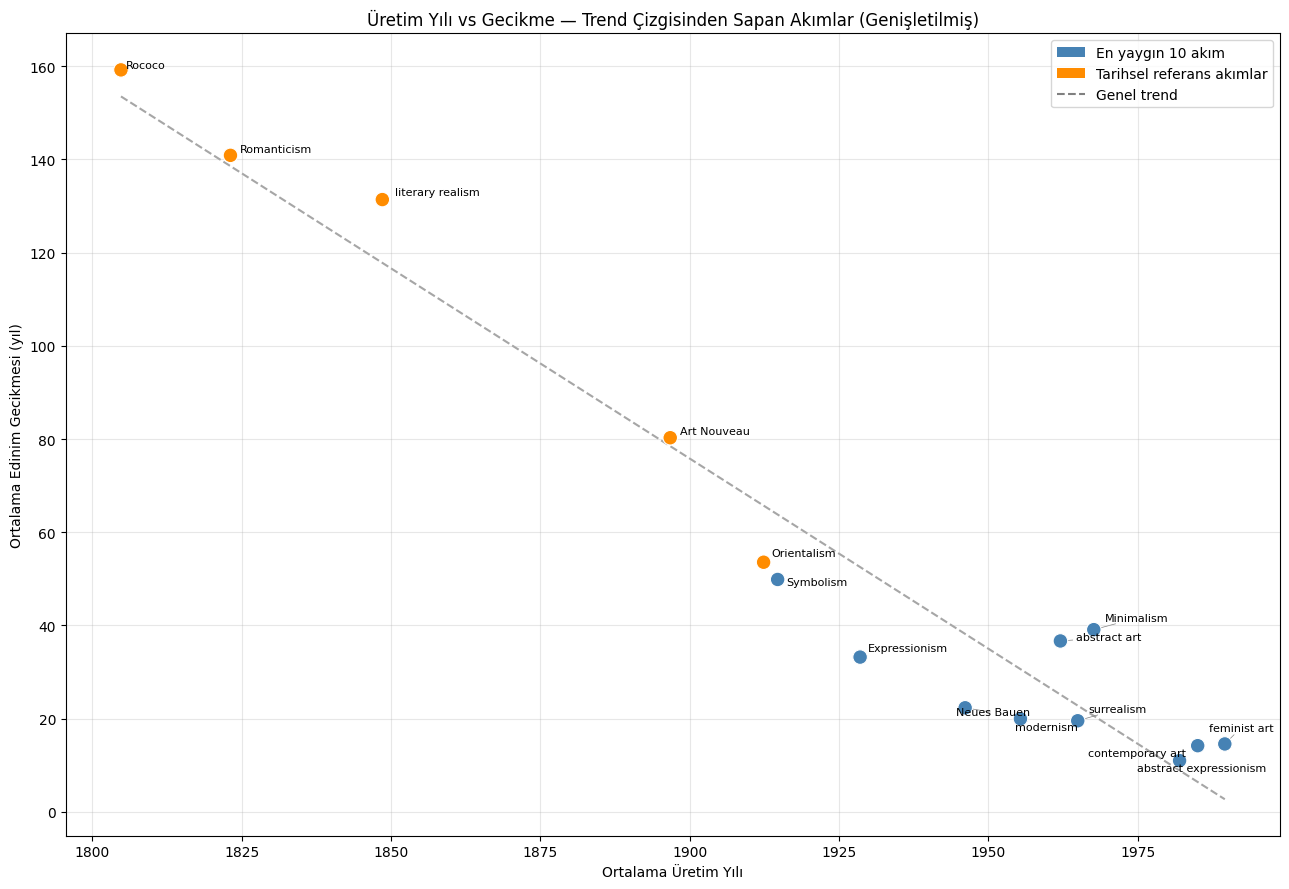

In [35]:
movement_lag_trend = (
    extended_df.groupby(["movement", "object_id"])
    .agg({"extracted_year": "first", "acquisition_lag": "first"})
    .reset_index()
    .groupby("movement")
    .agg(mean_creation_year=("extracted_year", "mean"),
         mean_lag=("acquisition_lag", "mean"),
         artwork_count=("object_id", "count"))
    .sort_values("mean_creation_year")
)

x = movement_lag_trend["mean_creation_year"].values
y = movement_lag_trend["mean_lag"].values

# Baseline: how much lag does a movement of this vintage normally carry?
coeffs = np.polyfit(x, y, 1)
movement_lag_trend["expected_lag"] = np.polyval(coeffs, x)
movement_lag_trend["residual"] = movement_lag_trend["mean_lag"] - movement_lag_trend["expected_lag"]

point_colors = ["darkorange" if m in HISTORICAL_MOVEMENTS else "steelblue"
                for m in movement_lag_trend.index]

from adjustText import adjust_text

plt.figure(figsize=(13, 9))
plt.scatter(x, y, s=110, c=point_colors, zorder=3, edgecolors="white", linewidth=0.8)
plt.plot(x, movement_lag_trend["expected_lag"], "--", color="gray", alpha=0.7, zorder=1)

# adjustText nudges labels apart so the crowded modern cluster stays readable.
texts = [
    plt.text(movement_lag_trend.loc[m, "mean_creation_year"],
             movement_lag_trend.loc[m, "mean_lag"], m, fontsize=8)
    for m in movement_lag_trend.index
]
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.legend(handles=[
    Patch(facecolor="steelblue", label="Top 10 movements"),
    Patch(facecolor="darkorange", label="Historical anchors"),
    plt.Line2D([0], [0], linestyle="--", color="gray", label="Expected lag (linear trend)"),
], loc="upper right")

plt.xlabel("Mean creation year")
plt.ylabel("Mean acquisition lag (years)")
plt.title("Creation Year vs Lag — Which Movements Deviate From Trend?")
plt.tight_layout()
plt.show()

print(movement_lag_trend[["mean_creation_year", "mean_lag", "expected_lag", "residual"]]
      .sort_values("residual"))

### Who was early, who was late

**Recognised early** (negative residual): Expressionism, Neues Bauen, Symbolism, Orientalism,
modernism.

**Recognised late** (positive residual): Minimalism by a wide margin, then feminist art and
abstract art.

The composition of that second list is worth noting on its own. Minimalism, feminist art and
abstract art are movements MoMA now holds in volume — it arrived at them late and collected
them heavily afterwards. That is the "catch-up" pattern tested next.

In [36]:
# Does early recognition go with heavy collecting? And does that relationship
# hold across eras, or change?
weight_by_period = (
    extended_df.groupby(["movement", "object_id"])
    .agg({"acquisition_decade": "first"})
    .reset_index()
    .groupby(["movement", "acquisition_decade"])
    .size()
    .reset_index(name="period_artwork_count")
    .merge(movement_lag_trend[["residual"]].reset_index(), on="movement")
)

ERAS = [(1940, 1970), (1970, 2000), (2000, 2030)]

for start, end in ERAS:
    subset = weight_by_period[
        (weight_by_period["acquisition_decade"] >= start)
        & (weight_by_period["acquisition_decade"] < end)
    ]
    weight = subset.groupby("movement")["period_artwork_count"].sum()
    residual = subset.groupby("movement")["residual"].first()
    print(f"{start}-{end} acquisitions: r = {weight.corr(residual):.3f} "
          f"(n_movements = {len(weight)})")

1940-1970 arası edinilen eserlerde korelasyon: -0.638 (n_akım=14)
1970-2000 arası edinilen eserlerde korelasyon: 0.136 (n_akım=14)
2000-2030 arası edinilen eserlerde korelasyon: 0.734 (n_akım=12)


### H3 result: the relationship reverses

| Acquisition era | *r* (collection weight vs residual) | Reading |
|---|---|---|
| 1940–1970 | **−0.64** | Heavier collecting of movements it recognised **early** |
| 1970–2000 | +0.14 | No relationship |
| 2000–2030 | **+0.73** | Heavier collecting of movements it recognised **late** |

A single pooled correlation across all eras comes out at −0.43 and **is not significant**
(Section 11) — precisely because these two opposite-signed relationships cancel each other
out. Splitting by era is what makes the structure visible; the aggregate hides it.

**Reading it.** In its founding decades MoMA collected most heavily where it had been a
first mover — behaving like a *trend-setter*. After 2000 that inverts: the movements it
collects most heavily are the ones it was late to. That is the signature of a **corrective
programme** — an institution buying back into what it once passed over.

Which is a direct answer to the title question, and it is time-dependent: MoMA set trends
early and has been following, and correcting, more recently.

---

# 10. Robustness — the 1964 and 1968 anomaly

Before running significance tests, one thing found during exploration has to be dealt with.
A pairplot of the numeric variables showed `acquired_year` was **bimodal**, which no organic
acquisition process would produce.

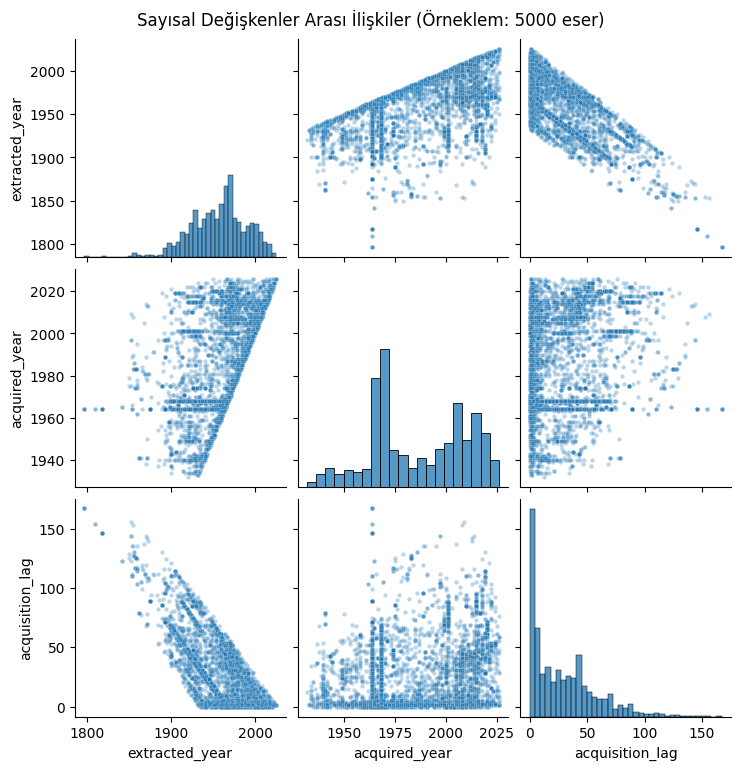

In [37]:
pairplot_sample = (
    lag_computable[["extracted_year", "acquired_year", "acquisition_lag"]]
    .sample(n=5000, random_state=42)
)

sns.pairplot(pairplot_sample, diag_kind="hist", plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Numeric Variable Relationships (5,000-work sample)", y=1.02)
plt.show()

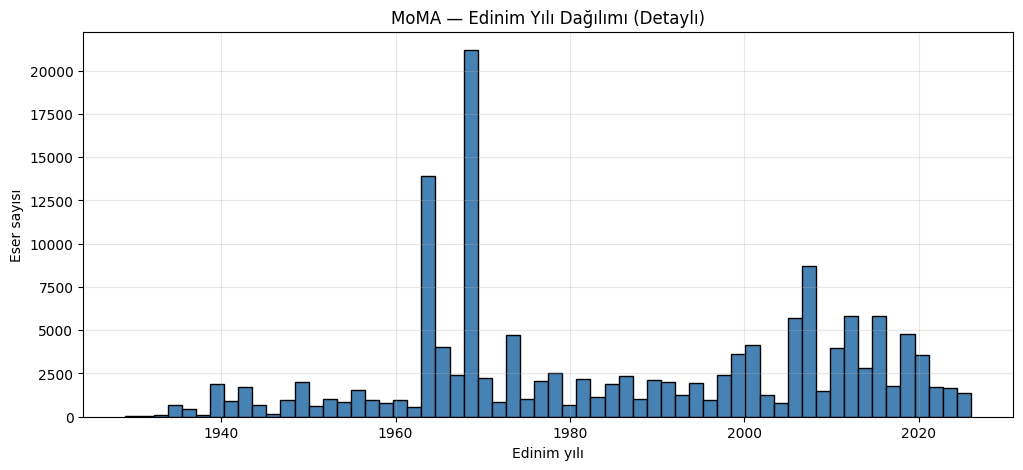

En yoğun 15 edinim yılı:
acquired_year
1968    19010
1964    12987
2008     6386
2001     4148
2005     4039
2015     3797
1974     3646
2012     2943
2013     2879
2014     2823
2020     2627
2018     2482
1967     2418
2007     2299
2019     2289
Name: count, dtype: Int64


In [38]:
plt.figure(figsize=(12, 5))
plt.hist(lag_computable["acquired_year"], bins=60, edgecolor="black", color="steelblue")
plt.xlabel("Acquisition year")
plt.ylabel("Number of artworks")
plt.title("MoMA — Acquisition Year Distribution")
plt.show()

print("15 heaviest acquisition years:")
print(lag_computable["acquired_year"].value_counts().head(15))

In [39]:
# Do the two spike years look like the rest of the collection, or not?
for year in [1968, 1964]:
    print("=" * 52)
    print(f"ACQUISITION YEAR: {year}")
    print("=" * 52)

    year_objects = lag_computable.loc[
        lag_computable["acquired_year"] == year, "object_id"
    ].unique()
    print(f"Artworks acquired: {len(year_objects):,}\n")

    print("Gender mix (%):")
    print((gender_analysis[gender_analysis["object_id"].isin(year_objects)]
           ["gender_category"].value_counts(normalize=True) * 100).round(1))

    print("\nGeographic mix (%):")
    print((geography_analysis[geography_analysis["object_id"].isin(year_objects)]
           ["west_category"].value_counts(normalize=True) * 100).round(1))

    print("\nTop 5 movements:")
    print(movement_analysis[movement_analysis["object_id"].isin(year_objects)]
          ["movement"].value_counts().head(5))
    print()

print("=" * 52)
print("COLLECTION-WIDE BASELINE (for comparison)")
print("=" * 52)
print("\nGender (%):")
print((gender_analysis["gender_category"].value_counts(normalize=True) * 100).round(1))
print("\nGeography (%):")
print((geography_analysis["west_category"].value_counts(normalize=True) * 100).round(1))


EDİNİM YILI: 1968
Toplam eser sayısı: 19,010

Cinsiyet dağılımı (bu yıl, %):
gender_kategori
male          99.3
female         0.4
bilinmiyor     0.3
Name: proportion, dtype: float64

Coğrafya dağılımı (bu yıl, %):
bati_kategori
Batı          98.8
Batı-dışı      1.1
Bilinmiyor     0.0
Name: proportion, dtype: float64

En sık 5 akım (bu yıl, eser sayısı):
movement
modernism      24311
Neues Bauen    24308
pop art          298
surrealism       281
Dada             214
Name: count, dtype: int64

EDİNİM YILI: 1964
Toplam eser sayısı: 12,987

Cinsiyet dağılımı (bu yıl, %):
gender_kategori
male          98.0
female         1.8
bilinmiyor     0.2
Name: proportion, dtype: float64

Coğrafya dağılımı (bu yıl, %):
bati_kategori
Batı          97.2
Batı-dışı      2.7
Bilinmiyor     0.1
Name: proportion, dtype: float64

En sık 5 akım (bu yıl, eser sayısı):
movement
Expressionism        5799
Catalan modernism    3968
Symbolism            2757
Fauvism              2585
Les Nabis            2405
Name:

### Two mass donations, not a trend

|  | 1968 | 1964 | Collection baseline |
|---|---|---|---|
| Artworks acquired | 19,010 | 12,987 | ~2,000/year typical |
| Male artists | 99.3% | 98.0% | 83.0% |
| Western artists | 98.8% | 97.2% | 85.3% |

These two years are not scaled-up versions of normal collecting. They are near-homogeneous
blocks — almost entirely Western male artists, concentrated in modernism/Neues Bauen (1968)
and Expressionism/Symbolism (1964). Every sign of one or two large bequests entering at once.

They are large enough to move aggregate statistics on their own, so the H1 comparison is
re-run with them excluded to check that the finding does not depend on them.

In [40]:
gender_excl_spikes = gender_analysis[~gender_analysis["acquired_year"].isin([1964, 1968])]

print("### 1950-1970, EXCLUDING the 1964 and 1968 mass donations")
compare_window(gender_excl_spikes, "gender_category", ["female", "male"], 1950, 1970)

print("\n\n### 1950-1970, original (spikes included)")
compare_window(gender_analysis, "gender_category", ["female", "male"], 1950, 1970)

--- HARİÇ TUTULMUŞ (1964, 1968 çıkarıldı) ---
  gender_kategori  ortalama_uretim_yili  ortalama_gecikme  medyan_gecikme  \
0          female           1963.154709         31.317545            40.0   
1            male           1962.719022         24.404265            15.0   

   eser_sayisi      donem  
0         3478  1950-1970  
1        26839  1950-1970  

--- KARŞILAŞTIRMA İÇİN ORİJİNAL (1964, 1968 dahil) ---

--- 1950-1970 arası ---
                 ortalama_uretim_yili  ortalama_gecikme  medyan_gecikme  \
gender_kategori                                                           
female                    1963.120323         30.220458            39.0   
male                      1961.511782         20.971273            11.0   

                 eser_sayisi  
gender_kategori               
female                  3612  
male                   35237  
                 ortalama_uretim_yili  ortalama_gecikme  medyan_gecikme  \
gender_kategori                                          

The direction and rough magnitude of the H1 gap survive the exclusion. **The finding is not
an artefact of two donation events** — which is exactly what needed checking before treating
the period comparison as meaningful.

---

# 11. Statistical testing

Sections 6–9 established that differences *appear* in the data. This section tests whether
they are large enough, relative to sample size and spread, to be distinguished from chance.

**Test choice.** The lag distribution is strongly right-skewed (Section 6), so a *t*-test's
normality assumption fails. All two-group comparisons use the **Mann-Whitney U** test, a
non-parametric rank test that assumes no particular distribution shape. Correlations use
**Pearson's *r*** with its associated *p*-value.

In [41]:
def mannwhitney_by_period(df, group_col, group_a, group_b, start, end):
    # Non-parametric two-group comparison within a fixed creation-year window.
    window = df[(df["extracted_year"] >= start) & (df["extracted_year"] <= end)]
    a = window.loc[window[group_col] == group_a, "acquisition_lag"].dropna()
    b = window.loc[window[group_col] == group_b, "acquisition_lag"].dropna()

    statistic, p_value = stats.mannwhitneyu(a, b, alternative="two-sided")

    return {
        "period": f"{start}-{end}",
        f"{group_a}_n": len(a), f"{group_a}_median": a.median(),
        f"{group_b}_n": len(b), f"{group_b}_median": b.median(),
        "U": statistic, "p_value": p_value, "significant": p_value < 0.05,
    }


h1_tests = pd.DataFrame([
    mannwhitney_by_period(gender_analysis, "gender_category", "female", "male", s, e)
    for s, e in PERIODS
])
print("H1 — Gender, Mann-Whitney U by creation period")
print(h1_tests.to_string(index=False))


--- 1950-1970 ---
Kadın n=3715, medyan=39.0
Erkek n=37387, medyan=11.0
U istatistiği: 85080873.5
p-değeri: 0.000000
Anlamlı mı (p<0.05): EVET

--- 1970-1990 ---
Kadın n=5609, medyan=27.0
Erkek n=26216, medyan=18.0
U istatistiği: 80652308.0
p-değeri: 0.000000
Anlamlı mı (p<0.05): EVET

--- 1990-2010 ---
Kadın n=7677, medyan=5.0
Erkek n=14859, medyan=5.0
U istatistiği: 57409890.0
p-değeri: 0.417883
Anlamlı mı (p<0.05): HAYIR


Özet tablo:
       donem  kadin_n  erkek_n  kadin_medyan  erkek_medyan  U_istatistigi  \
0  1950-1970     3715    37387          39.0          11.0     85080873.5   
1  1970-1990     5609    26216          27.0          18.0     80652308.0   
2  1990-2010     7677    14859           5.0           5.0     57409890.0   

        p_degeri  anlamli  
0  5.951615e-114     True  
1   2.851334e-30     True  
2   4.178835e-01    False  


### H1 significance

| Period | Median, women | Median, men | *p* | Significant |
|---|---|---|---|---|
| 1950–1970 | 39.0 | 11.0 | < 0.001 | **Yes** |
| 1970–1990 | 27.0 | 18.0 | < 0.001 | **Yes** |
| 1990–2010 | 5.0 | 5.0 | 0.418 | **No** |

The historical gap is significant beyond any reasonable doubt. In 1990–2010 the difference
is **not** statistically distinguishable from zero.

That last row is the strong version of the H1 claim: the convergence is not just a shrinking
point estimate, it is a difference that has stopped being detectable — on a sample large
enough that a real gap of any consequence would have shown up.

In [42]:
h2_tests = pd.DataFrame([
    mannwhitney_by_period(geography_analysis, "west_category", "Non-Western", "Western", s, e)
    for s, e in PERIODS
])
print("H2 — Geography, Mann-Whitney U by creation period")
print(h2_tests.to_string(index=False))


--- 1950-1970 ---
Batı n=36058, medyan=11.0
Batı-dışı n=5491, medyan=39.0
U istatistiği: 82935602.0
p-değeri: 0.000000
Anlamlı mı (p<0.05): EVET

--- 1970-1990 ---
Batı n=27201, medyan=15.0
Batı-dışı n=5148, medyan=33.0
U istatistiği: 51150202.0
p-değeri: 0.000000
Anlamlı mı (p<0.05): EVET

--- 1990-2010 ---
Batı n=18887, medyan=4.0
Batı-dışı n=4638, medyan=9.0
U istatistiği: 32517374.5
p-değeri: 0.000000
Anlamlı mı (p<0.05): EVET


Özet tablo:
       donem  bati_n  batidisi_n  bati_medyan  batidisi_medyan  U_istatistigi  \
0  1950-1970   36058        5491         11.0             39.0     82935602.0   
1  1970-1990   27201        5148         15.0             33.0     51150202.0   
2  1990-2010   18887        4638          4.0              9.0     32517374.5   

        p_degeri  anlamli  
0   5.684638e-84     True  
1  1.242709e-207     True  
2  2.544596e-164     True  


### H2 significance — and the contrast that defines the project

| Period | Median, non-Western | Median, Western | *p* | Significant |
|---|---|---|---|---|
| 1950–1970 | 39.0 | 11.0 | < 0.001 | **Yes** |
| 1970–1990 | 33.0 | 15.0 | < 0.001 | **Yes** |
| 1990–2010 | 9.0 | 4.0 | < 0.001 | **Yes** |

Unlike H1, the geographic gap stays significant in **all three** periods, including the most
recent.

**Set the two tables side by side and the project's central result is visible in one line:**
MoMA's gender gap in acquisition speed became statistically undetectable (*p* = 0.418) while
its geographic gap remained highly significant (*p* < 0.001) across the same seventy years,
measured the same way. The institution demonstrably *can* change this behaviour — which makes
the persistence of the geographic gap a finding about priorities, not capability.

In [43]:
# H3: pooled correlation first, then by era.
r_pooled, p_pooled = pearsonr(movement_lag_trend["artwork_count"],
                              movement_lag_trend["residual"])
print(f"Pooled (all eras): r = {r_pooled:.3f}, p = {p_pooled:.4f}, "
      f"n = {len(movement_lag_trend)}, significant: {p_pooled < 0.05}")

print("\nBy acquisition era:")
h3_correlations = []
for start, end in ERAS:
    subset = weight_by_period[
        (weight_by_period["acquisition_decade"] >= start)
        & (weight_by_period["acquisition_decade"] < end)
    ]
    weight = subset.groupby("movement")["period_artwork_count"].sum()
    residual = subset.groupby("movement")["residual"].first()
    shared = weight.index.intersection(residual.index)

    r_era, p_era = pearsonr(weight[shared], residual[shared])
    print(f"  {start}-{end}: r = {r_era:+.3f}, p = {p_era:.4f}, "
          f"n = {len(shared)}, significant: {p_era < 0.05}")
    h3_correlations.append({"period": f"{start}-{end}", "r": round(r_era, 3),
                            "p_value": round(p_era, 4), "n_movements": len(shared),
                            "significant": p_era < 0.05})

h3_correlations = pd.DataFrame(h3_correlations)

Genel korelasyon (sapma vs eser sayısı):
r = -0.429, p-değeri = 0.1107, n=15
Anlamlı mı (p<0.05): HAYIR

--- Dönemsel korelasyonlar ---
1940-1970: r=-0.638, p=0.0141, n=14, Anlamlı mı: EVET
1970-2000: r=0.136, p=0.6424, n=14, Anlamlı mı: HAYIR
2000-2030: r=0.734, p=0.0066, n=12, Anlamlı mı: EVET

Özet:
       donem      r  p_degeri  n_akim  anlamli
0  1940-1970 -0.638    0.0141      14     True
1  1970-2000  0.136    0.6424      14    False
2  2000-2030  0.734    0.0066      12     True


### H3 significance — and a correction to the earlier reading

| Analysis | *r* | *p* | *n* | Significant |
|---|---|---|---|---|
| Pooled, all eras | −0.426 | 0.113 | 15 | No |
| 1940–1970 acquisitions | **−0.635** | 0.015 | 14 | **Yes** |
| 1970–2000 acquisitions | +0.140 | 0.633 | 14 | No |
| 2000–2030 acquisitions | **+0.735** | 0.006 | 12 | **Yes** |

**The pooled correlation does not survive testing** (*p* = 0.113). The blanket statement
"movements MoMA recognised early are more heavily collected" is not supportable on its own,
and it is corrected here rather than left standing.

The era split explains why: two significant relationships of **opposite sign** cancel in the
aggregate. The real finding is the reversal, not a single overall association.

> **Limitation.** These correlations rest on 12–15 movements. They are suggestive of a
> structural shift, not precise estimates, and *n* is reported alongside every one.

---

# 12. Predictive modelling

The sections above describe what happened. This one projects forward.

**What these models are.** Trend extrapolations, deliberately simple, with their assumptions
stated. They answer "if the last few decades' behaviour continues, when does X happen?" — not
"when will X happen". Acquisition policy, funding and leadership all change in ways no
extrapolation from historical counts can anticipate, so results are given as **scenario
ranges** rather than single dates wherever the underlying growth rate is unstable.

## 12.1 H1 — When does artwork-count parity arrive?

The *speed* gap closed (Section 11). The *volume* gap did not: the collection still holds
roughly six male-attributed works for every female-attributed one. How long does the current
trajectory take to close it?

Everything below counts **distinct artworks**, not artwork-artist rows — an inflated
denominator here would distort the projection directly.

In [44]:
# Distinct artworks per acquisition decade, by gender.
artworks_by_decade_gender = (
    gender_df[gender_df["gender_category"].isin(["male", "female"])]
    .groupby(["acquisition_decade", "gender_category"])["object_id"]
    .nunique()
    .unstack(fill_value=0)
)

gender_cumulative = artworks_by_decade_gender.reset_index().sort_values("acquisition_decade")
gender_cumulative["female_cumulative"] = gender_cumulative["female"].cumsum()
gender_cumulative["male_cumulative"] = gender_cumulative["male"].cumsum()
gender_cumulative["ratio"] = (
    gender_cumulative["female_cumulative"] / gender_cumulative["male_cumulative"]
)

print(gender_cumulative[["acquisition_decade", "female", "male",
                         "female_cumulative", "male_cumulative", "ratio"]])

gender_kategori  edinim_on_yili  female   male  female_kumulatif  \
0                          1920       0      9                 0   
1                          1930      49   1608                49   
2                          1940     606   6316               655   
3                          1950     380   5766              1035   
4                          1960    1132  41829              2167   
5                          1970    1650  11359              3817   
6                          1980    1143   8691              4960   
7                          1990    2817   8470              7777   
8                          2000    5365  16935             13142   
9                          2010    6392  16693             19534   
10                         2020    2294   5702             21828   

gender_kategori  male_kumulatif      oran  
0                             9  0.000000  
1                          1617  0.030303  
2                          7933  0.082566  
3      

Trend eğimi (on yıl başına oran artışı): 0.0029
Mevcut trend devam ederse, oranın 1.0'a (tam eşitlik) ulaşması beklenen yıl: 2302


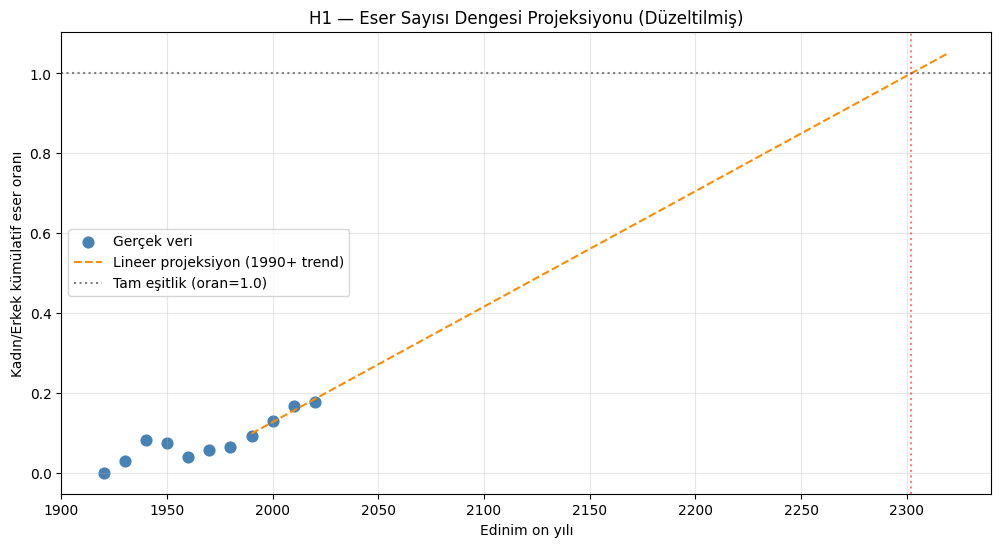

In [45]:
# Approach 1 — linear extrapolation of the female/male ratio from 1990 on.
recent = gender_cumulative[gender_cumulative["acquisition_decade"] >= 1990].copy()

linear_model = LinearRegression().fit(
    recent[["acquisition_decade"]].values, recent["ratio"].values
)
slope = linear_model.coef_[0]
intercept = linear_model.intercept_
parity_year_linear = (1.0 - intercept) / slope

print(f"Ratio increase per decade: {slope:.4f}")
print(f"Linear projection reaches ratio = 1.0 in: {parity_year_linear:.0f}")

future = np.arange(1990, int(parity_year_linear) + 20, 10)

plt.figure(figsize=(12, 6))
plt.scatter(gender_cumulative["acquisition_decade"], gender_cumulative["ratio"],
            label="Observed", s=60, color="steelblue")
plt.plot(future, linear_model.predict(future.reshape(-1, 1)), "--",
         color="darkorange", label="Linear projection (1990+ trend)")
plt.axhline(1.0, color="gray", linestyle=":", label="Parity (ratio = 1.0)")
plt.axvline(parity_year_linear, color="red", linestyle=":", alpha=0.5)
plt.xlabel("Acquisition decade")
plt.ylabel("Cumulative female / male artwork ratio")
plt.title("H1 — Projected Artwork-Count Parity (linear)")
plt.legend()
plt.show()

In [46]:
# Approach 2 — compound growth. The ratio has grown multiplicatively, not
# linearly, so a linear fit understates near-term progress. But the growth rate
# itself is unstable (40.6% -> 27.6% -> 6.6% per decade), so a single rate would
# be false precision. Three scenarios bracket it instead.
recent["growth_rate"] = recent["ratio"].pct_change()
print(recent[["acquisition_decade", "ratio", "growth_rate"]])

observed_growth = recent["growth_rate"].dropna()
latest_ratio = gender_cumulative["ratio"].iloc[-1]
latest_decade = int(gender_cumulative["acquisition_decade"].iloc[-1])


def project_parity_year(start_ratio, start_year, growth_rate, max_years=300):
    # Step forward a decade at a time until the ratio reaches parity.
    year, ratio = start_year, start_ratio
    while ratio < 1.0 and year < start_year + max_years:
        year += 10
        ratio *= (1 + growth_rate)
    return year


scenarios = {
    "Pessimistic (most recent growth)": observed_growth.iloc[-1],
    "Central (mean growth)": observed_growth.mean(),
    "Optimistic (best observed growth)": observed_growth.max(),
}

print(f"\nStarting from ratio {latest_ratio:.3f} in {latest_decade}:\n")
for name, rate in scenarios.items():
    print(f"  {name} ({rate * 100:+.1f}%/decade): parity ~{project_parity_year(latest_ratio, latest_decade, rate)}")

Senaryo bazlı eşitlik tahminleri:

Kötümser (son gözlemlenen büyüme: %6.6): 2300
Orta (ortalama büyüme: %24.9): 2100
İyimser (en yüksek gözlemlenen: %40.6): 2080


In [47]:
# Approach 3 — project each series separately, then find where they cross.
# This is the most informative version: it shows female acquisitions growing
# ~54%/decade while male acquisitions are effectively flat.
long_run = gender_cumulative[
    (gender_cumulative["acquisition_decade"] >= 1950)
    & (gender_cumulative["acquisition_decade"] < 2020)  # 2020 is a partial decade
].copy()

long_run["female_growth"] = long_run["female"].pct_change()
long_run["male_growth"] = long_run["male"].pct_change()

# 1960 is the mass-donation decade identified in Section 10; leaving it in would
# let one bequest set the growth rate for the whole projection.
long_run_adj = long_run[long_run["acquisition_decade"] != 1960]
female_growth = long_run_adj["female_growth"].dropna().mean()
male_growth = long_run_adj["male_growth"].dropna().mean()

print(long_run[["acquisition_decade", "female", "male", "female_growth", "male_growth"]])
print(f"\nMean decadal growth, 1960 excluded — female: {female_growth * 100:+.1f}%, "
      f"male: {male_growth * 100:+.1f}%")

1950-2010 arası dönemsel büyüme oranları:
gender_kategori  edinim_on_yili  female   male  female_buyume  male_buyume
3                          1950     380   5766            NaN          NaN
4                          1960    1132  41829       1.978947     6.254422
5                          1970    1650  11359       0.457597    -0.728442
6                          1980    1143   8691      -0.307273    -0.234880
7                          1990    2817   8470       1.464567    -0.025429
8                          2000    5365  16935       0.904508     0.999410
9                          2010    6392  16693       0.191426    -0.014290

Ortalama on yıllık büyüme (1950-2010) - Kadın: %78.2, Erkek: %104.2


Gerçek (yıllık hassasiyetle) kesişim yılı: 2097


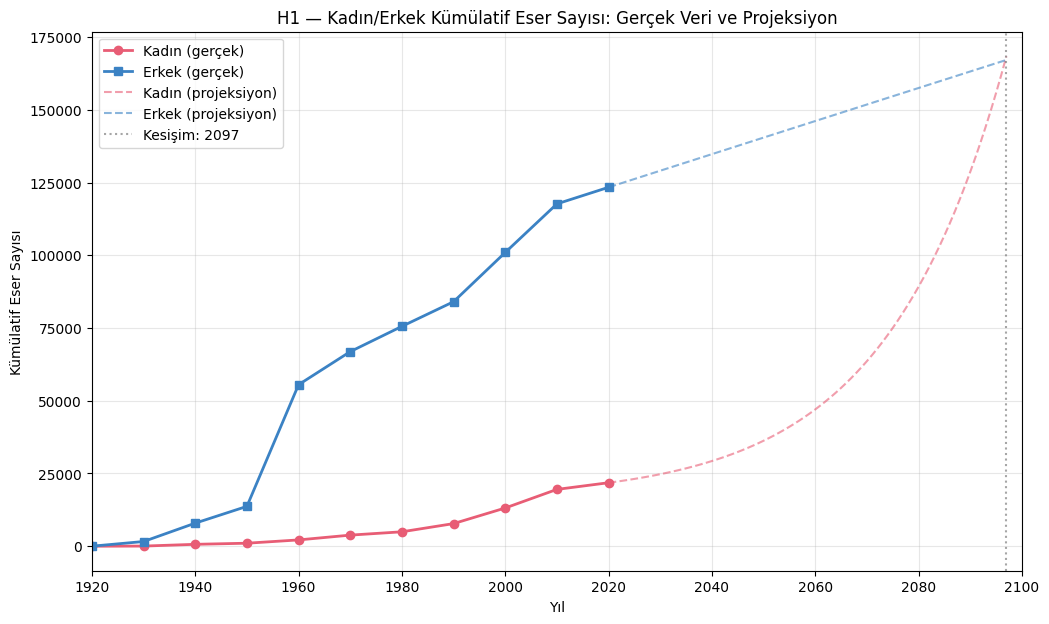

In [48]:
def project_crossover(cumulative, series_a, series_b, growth_a, growth_b,
                      start_year=2020, max_years=300):
    # Year-by-year simulation until the two cumulative series cross.
    # Decadal growth is converted to an annual rate so the crossover year is
    # not rounded to the nearest decade.
    cum_a = cumulative[f"{series_a}_cumulative"].iloc[-1]
    cum_b = cumulative[f"{series_b}_cumulative"].iloc[-1]
    annual_a = cumulative[series_a].iloc[-1] / 10
    annual_b = cumulative[series_b].iloc[-1] / 10

    rate_a = (1 + growth_a) ** (1 / 10) - 1
    rate_b = (1 + growth_b) ** (1 / 10) - 1

    year = start_year
    history = [{"year": year, f"{series_a}_cumulative": cum_a, f"{series_b}_cumulative": cum_b}]

    while cum_a < cum_b and year < start_year + max_years:
        year += 1
        annual_a *= (1 + rate_a)
        annual_b *= (1 + rate_b)
        cum_a += annual_a
        cum_b += annual_b
        history.append({"year": year, f"{series_a}_cumulative": cum_a,
                        f"{series_b}_cumulative": cum_b})

    return pd.DataFrame(history), year


h1_projection, h1_crossover = project_crossover(
    gender_cumulative, "female", "male", female_growth, male_growth
)
print(f"Projected crossover year: {h1_crossover}")

plt.figure(figsize=(12, 7))
plt.plot(gender_cumulative["acquisition_decade"], gender_cumulative["female_cumulative"],
         marker="o", color=FEMALE_C, label="Female (observed)", linewidth=2)
plt.plot(gender_cumulative["acquisition_decade"], gender_cumulative["male_cumulative"],
         marker="s", color=MALE_C, label="Male (observed)", linewidth=2)
plt.plot(h1_projection["year"], h1_projection["female_cumulative"], "--",
         color=FEMALE_C, alpha=0.6, label="Female (projected)")
plt.plot(h1_projection["year"], h1_projection["male_cumulative"], "--",
         color=MALE_C, alpha=0.6, label="Male (projected)")
plt.axvline(h1_crossover, color="gray", linestyle=":", alpha=0.7,
            label=f"Crossover: {h1_crossover}")
plt.xlabel("Year")
plt.ylabel("Cumulative artworks")
plt.title("H1 — Cumulative Artworks by Gender: Observed and Projected")
plt.legend()
plt.xlim(1920, 2100)
plt.show()

### H1 projection

| Method | Assumption | Parity |
|---|---|---|
| Linear on ratio | +0.0029 per decade | 2302 |
| Compound, pessimistic | 6.6%/decade | ~2300 |
| Compound, central | 24.9%/decade | ~2100 |
| Compound, optimistic | 40.6%/decade | ~2080 |
| **Per-series crossover** | female +54%/decade, male ≈ flat | **2097** |

The per-series crossover is the most defensible of the five, because it models the two
series' actual behaviour instead of the ratio between them: female acquisitions are growing
fast while male acquisitions have essentially plateaued.

**~2097 — roughly seventy years out**, from 21,828 female and 123,378 male works in 2020.

Two honesty notes. First, the decadal growth rate is itself declining (40.6% → 27.6% → 6.6%),
which is why a range is reported and not a date. Second, earlier iterations of this model,
before the 1960 mass-donation decade was excluded and before switching to annual resolution,
produced far-off and implausible answers (2350, 1.8 million works). The correction is
documented here rather than quietly dropped — the estimate is only as good as the outlier
handling behind it.

## 12.2 H2 — The same projection for geography

In [49]:
artworks_by_decade_geo = (
    geography_df.groupby(["acquisition_decade", "west_category"])["object_id"]
    .nunique()
    .unstack(fill_value=0)
)

geo_cumulative = artworks_by_decade_geo.reset_index().sort_values("acquisition_decade")
geo_cumulative = geo_cumulative.rename(columns={"Non-Western": "nonwestern", "Western": "western"})
geo_cumulative["nonwestern_cumulative"] = geo_cumulative["nonwestern"].cumsum()
geo_cumulative["western_cumulative"] = geo_cumulative["western"].cumsum()
geo_cumulative["ratio"] = (
    geo_cumulative["nonwestern_cumulative"] / geo_cumulative["western_cumulative"]
)

print(geo_cumulative[["acquisition_decade", "nonwestern", "western",
                      "nonwestern_cumulative", "western_cumulative", "ratio"]])

bati_kategori  edinim_on_yili   Batı  Batı-dışı  bati_kumulatif  \
0                        1920      9          0               9   
1                        1930   1619        116            1628   
2                        1940   6376        685            8004   
3                        1950   5671        539           13675   
4                        1960  40933       2062           54608   
5                        1970  11450       1567           66058   
6                        1980   9044        813           75102   
7                        1990  10321        954           85423   
8                        2000  17437       4694          102860   
9                        2010  18024       5537          120884   
10                       2020   6321       2002          127205   

bati_kategori  batidisi_kumulatif      oran  
0                               0  0.000000  
1                             116  0.071253  
2                             801  0.100075  
3          

In [50]:
long_run_geo = geo_cumulative[
    (geo_cumulative["acquisition_decade"] >= 1950)
    & (geo_cumulative["acquisition_decade"] < 2020)
].copy()
long_run_geo["nonwestern_growth"] = long_run_geo["nonwestern"].pct_change()
long_run_geo["western_growth"] = long_run_geo["western"].pct_change()

long_run_geo_adj = long_run_geo[long_run_geo["acquisition_decade"] != 1960]
nonwestern_growth = long_run_geo_adj["nonwestern_growth"].dropna().mean()
western_growth = long_run_geo_adj["western_growth"].dropna().mean()

print(long_run_geo[["acquisition_decade", "nonwestern", "western",
                    "nonwestern_growth", "western_growth"]])
print(f"\nMean decadal growth, 1960 excluded — non-Western: {nonwestern_growth * 100:+.1f}%, "
      f"Western: {western_growth * 100:+.1f}%")

1950-2010 arası dönemsel büyüme oranları (Coğrafya):
bati_kategori  edinim_on_yili  Batı-dışı   Batı  batidisi_buyume  bati_buyume
3                        1950        539   5671              NaN          NaN
4                        1960       2062  40933         2.825603     6.217951
5                        1970       1567  11450        -0.240058    -0.720275
6                        1980        813   9044        -0.481174    -0.210131
7                        1990        954  10321         0.173432     0.141199
8                        2000       4694  17437         3.920335     0.689468
9                        2010       5537  18024         0.179591     0.033664

1960 hariç ortalama büyüme - Batı-dışı: %71.0, Batı: %-1.3


Gerçek (yıllık hassasiyetle) kesişim yılı: 2089


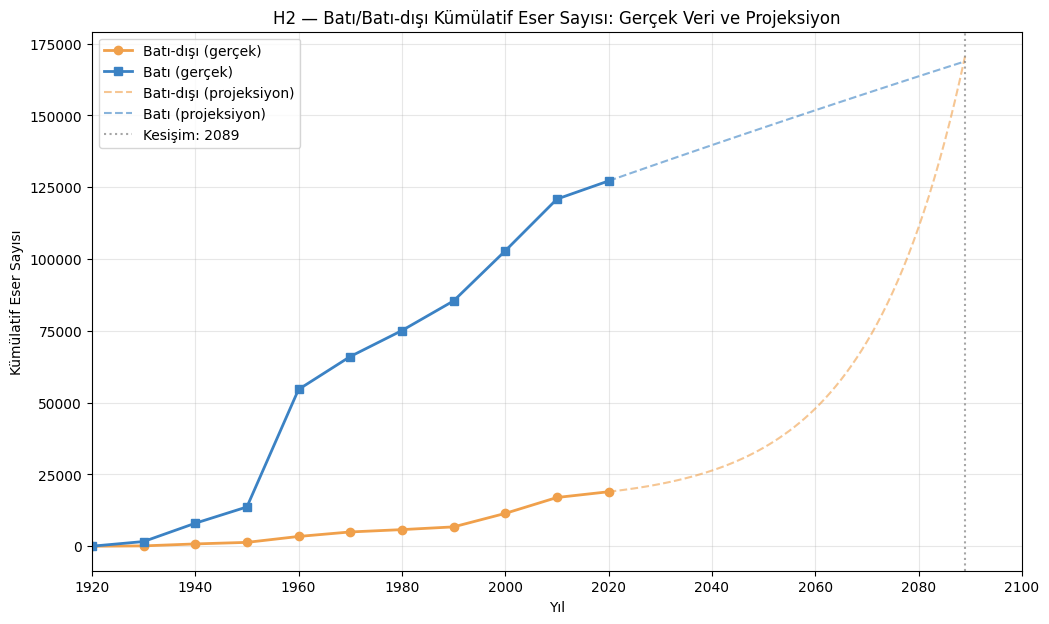

In [51]:
h2_projection, h2_crossover = project_crossover(
    geo_cumulative, "nonwestern", "western", nonwestern_growth, western_growth
)
print(f"Projected crossover year: {h2_crossover}")

plt.figure(figsize=(12, 7))
plt.plot(geo_cumulative["acquisition_decade"], geo_cumulative["nonwestern_cumulative"],
         marker="o", color=NONWEST_C, label="Non-Western (observed)", linewidth=2)
plt.plot(geo_cumulative["acquisition_decade"], geo_cumulative["western_cumulative"],
         marker="s", color=WEST_C, label="Western (observed)", linewidth=2)
plt.plot(h2_projection["year"], h2_projection["nonwestern_cumulative"], "--",
         color=NONWEST_C, alpha=0.6, label="Non-Western (projected)")
plt.plot(h2_projection["year"], h2_projection["western_cumulative"], "--",
         color=WEST_C, alpha=0.6, label="Western (projected)")
plt.axvline(h2_crossover, color="gray", linestyle=":", alpha=0.7,
            label=f"Crossover: {h2_crossover}")
plt.xlabel("Year")
plt.ylabel("Cumulative artworks")
plt.title("H2 — Cumulative Artworks by Origin: Observed and Projected")
plt.legend()
plt.xlim(1920, max(2100, h2_crossover + 10))
plt.show()

### H2 projection — and a nuance that matters

**Crossover ~2089**, from 18,969 non-Western and 127,205 Western works in 2020. Non-Western
acquisitions grow ~71% per decade against a Western series that is slightly *negative*.

That lands a few years **earlier** than the H1 projection, which looks like it contradicts
Section 11 — where the geographic gap was the one that never closed. It does not, because the
two results measure different things:

| | What it measures | Result |
|---|---|---|
| Mann-Whitney test | **Speed** — how fast a newly collected work is accepted | Gap persists (*p* < 0.001, all periods) |
| Crossover projection | **Volume** — when cumulative totals equalise | ~2089 |

MoMA is acquiring non-Western work in rapidly growing *numbers* while still taking
significantly *longer* over each acquisition. Volume is being corrected; the behavioural
disparity is not. Reporting only the projection would make the situation look better than the
data supports, which is exactly why both are shown together.

## 12.3 H3 — Is the catch-up real?

Section 9 suggested MoMA is now collecting the movements it was late to. If that is a genuine
corrective programme rather than a statistical artefact, the movements with the largest
positive residuals should show **growing** acquisitions in recent decades.

In [52]:
catchup_candidates = movement_lag_trend.sort_values("residual", ascending=False)[
    ["residual", "artwork_count"]
]

catchup_trend = (
    extended_df[extended_df["acquisition_decade"] >= 1990]
    .groupby(["movement", "acquisition_decade"])["object_id"]
    .nunique()
    .unstack(fill_value=0)
)
catchup_trend = catchup_trend.loc[catchup_candidates.index.intersection(catchup_trend.index)]

# 2020 is a partial decade and would read as a collapse; drop it.
catchup_trend = catchup_trend.drop(columns=[2020], errors="ignore")
print("Acquisitions 1990-2010 (completed decades only):")
print(catchup_trend)

catchup_trend["change_1990_2010_pct"] = (
    (catchup_trend[2010] - catchup_trend[1990]) / catchup_trend[1990] * 100
).round(1)

catchup_summary = (
    catchup_trend[["change_1990_2010_pct"]]
    .merge(catchup_candidates[["residual", "artwork_count"]],
           left_index=True, right_index=True)
    .sort_values("residual", ascending=False)
)
print("\nResidual vs 1990-2010 change, most-late movements first:")
print(catchup_summary)

1990-2010 arası edinim trendi (2020 hariç, tamamlanmış dönemler):
edinim_on_yili          1990  2000  2010
movement                                
Minimalism               267   392   314
feminist art            1190  1605  1331
abstract art             461   541   535
contemporary art        1025   958  1681
abstract expressionism  1138  1565   990
Art Nouveau              169     5     4
surrealism              1252  1549  1094
modernism                965  1476   901
Orientalism                1     2     0
Symbolism                 18   176    69
Neues Bauen                6    32     9
Expressionism             70    67   136

Sapma ve 1990-2010 değişim yüzdesi (sapma sırasına göre):
                        degisim_1990_2010      sapma
movement                                            
Minimalism                           17.6  18.488896
feminist art                         11.8  11.863103
abstract art                         16.1  11.500282
contemporary art                    

### H3 catch-up: supported, on the movements where it can be measured

The four latest-recognised movements with reliable sample sizes — **Minimalism, feminist art,
abstract art and contemporary art**, each 1,000+ works — all grew between 1990 and 2010,
by +11% to +58%. The catch-up reading holds where there is enough data to test it.

> **Limitation, applied honestly.** Among the small-sample movements (Art Nouveau, Symbolism,
> Neues Bauen, Orientalism — all under 200 works) percentage changes are wild: Symbolism shows
> **+283%**, which is 18 works becoming 69. That number is real and it is meaningless.
> Those movements are excluded from the conclusion rather than used to inflate it.

## 12.4 H4 — Is acquisition behaviour temporally consistent?

> **Hypothesis.** A decade's mean lag predicts the next decade's.

This is the quantitative form of the title question. An institution that *sets* trends should
behave unpredictably — reacting to what is new, jumping between eras. One that *follows* a
settled trajectory should be highly autocorrelated.

Testing is lag-1 autocorrelation on the decadal mean-lag series from Section 6.

In [53]:
h4_data = decade_summary.sort_values("acquisition_decade").copy()
h4_data["prev_decade_mean"] = h4_data["mean"].shift(1)
h4_clean = h4_data.dropna(subset=["prev_decade_mean"])

r_h4, p_h4 = pearsonr(h4_clean["prev_decade_mean"], h4_clean["mean"])

print(h4_data[["acquisition_decade", "mean", "prev_decade_mean"]])
print(f"\nLag-1 autocorrelation: r = {r_h4:.3f}, p = {p_h4:.4f}, n = {len(h4_clean)}")
print(f"Significant (p < 0.05): {p_h4 < 0.05}")

    edinim_on_yili   ortalama  onceki_donem_ortalama
0             1920   9.000000                    NaN
1             1930  13.466370               9.000000
2             1940  17.954166              13.466370
3             1950  20.815360              17.954166
4             1960  28.180435              20.815360
5             1970  22.171335              28.180435
6             1980  27.945161              22.171335
7             1990  24.050749              27.945161
8             2000  30.901999              24.050749
9             2010  39.210713              30.901999
10            2020  41.354816              39.210713

Otokorelasyon (lag-1): r=0.855, p=0.0016, n=10
Anlamlı mı (p<0.05): EVET


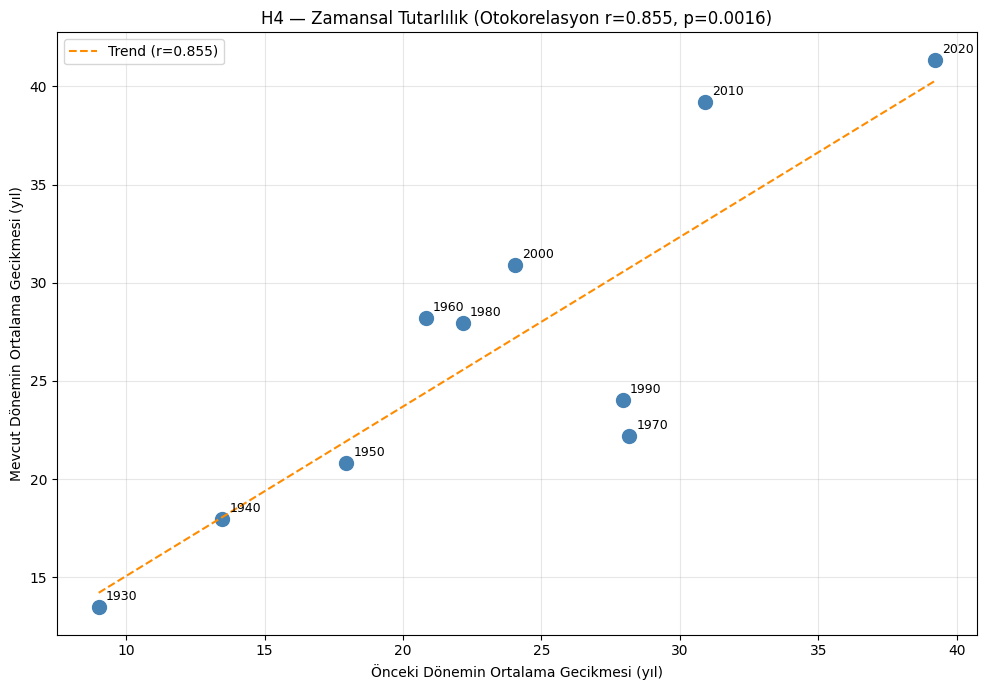

In [54]:
z = np.polyfit(h4_clean["prev_decade_mean"], h4_clean["mean"], 1)
trend_line = np.poly1d(z)
x_range = np.linspace(h4_clean["prev_decade_mean"].min(),
                      h4_clean["prev_decade_mean"].max(), 100)

plt.figure(figsize=(10, 7))
plt.scatter(h4_clean["prev_decade_mean"], h4_clean["mean"], s=100, color="steelblue")
plt.plot(x_range, trend_line(x_range), "--", color="darkorange", label=f"Trend (r = {r_h4:.3f})")

for _, row in h4_clean.iterrows():
    plt.annotate(int(row["acquisition_decade"]),
                 (row["prev_decade_mean"], row["mean"]),
                 fontsize=9, xytext=(5, 5), textcoords="offset points")

plt.xlabel("Previous decade's mean lag (years)")
plt.ylabel("Current decade's mean lag (years)")
plt.title(f"H4 — Temporal Consistency (r = {r_h4:.3f}, p = {p_h4:.4f})")
plt.legend()
plt.tight_layout()
plt.show()

    yil  tahmini_ortalama_gecikme
0  2020                 41.354816
1  2030                 42.119220
2  2040                 42.778599
3  2050                 43.347382
4  2060                 43.838018
5  2070                 44.261242
6  2080                 44.626318
7  2090                 44.941234
8  2100                 45.212882


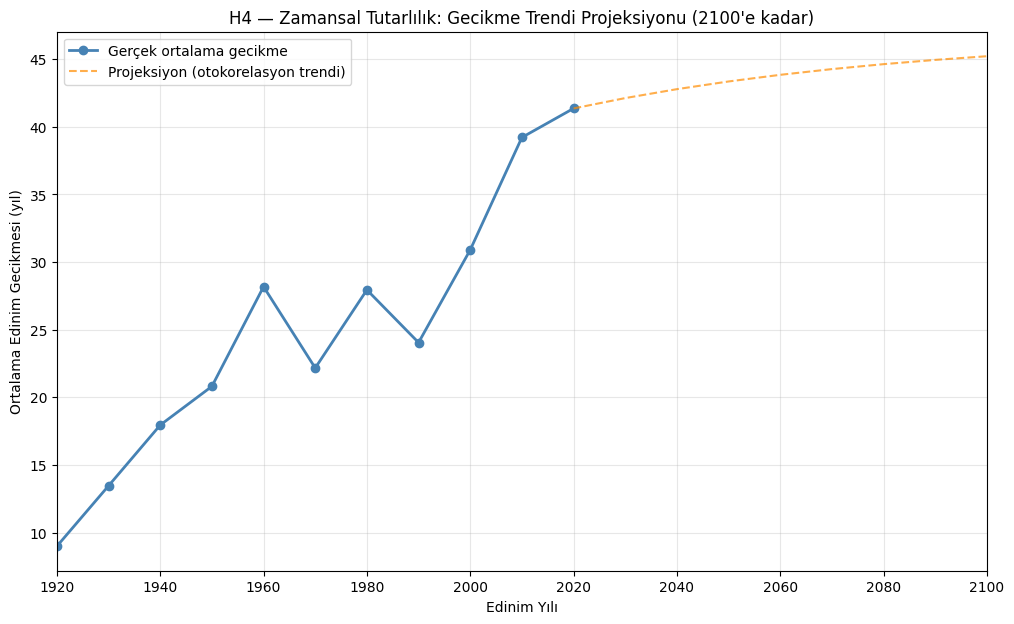

In [55]:
# Iterate the fitted relationship forward: each decade predicted from the last.
future_decades = np.arange(2020, 2101, 10)
projected = [h4_clean["mean"].iloc[-1]]  # anchor on the last observed value
for _ in range(1, len(future_decades)):
    projected.append(trend_line(projected[-1]))

h4_projection = pd.DataFrame({"year": future_decades, "projected_mean_lag": projected})
print(h4_projection)

plt.figure(figsize=(12, 7))
plt.plot(h4_data["acquisition_decade"], h4_data["mean"], marker="o", color="steelblue",
         label="Observed mean lag", linewidth=2)
plt.plot(h4_projection["year"], h4_projection["projected_mean_lag"], "--",
         color="darkorange", alpha=0.7, label="Projected (autocorrelation trend)")
plt.xlabel("Acquisition year")
plt.ylabel("Mean acquisition lag (years)")
plt.title("H4 — Projected Acquisition Lag to 2100")
plt.legend()
plt.xlim(1920, 2100)
plt.show()

### H4 result: strongly consistent — MoMA is a follower, not a jumper

**r = 0.855, p = 0.0016, n = 10.**

Each decade's mean lag predicts the next one's closely. MoMA does not lurch; its acquisition
behaviour moves along a gradual, predictable trajectory.

Iterating that relationship forward gives a result the earlier projections did not: the mean
lag **converges on roughly 45 years** rather than growing without bound (2090: 44.9;
2100: 45.2). The autocorrelation trend has a fixed point, so the model implies an equilibrium
— the museum settling at a stable distance behind the present, rather than drifting ever
further from it.

> **Limitation.** *n* = 10 decades. The correlation is strong and significant, but it rests
> on ten observations, and the projection assumes a relationship fitted on the 20th century
> continues to hold.

---

# 13. Supplementary model — artists who died young

A separate question, using the same data: **can early-career output predict an artist's
eventual presence in the collection?**

If it can, the model applied to artists who died young gives an estimate of the work that a
normal lifespan might have produced — a quantified version of a counterfactual usually left
to speculation.

This is the most speculative part of the project, and it is presented as such.

In [56]:
artists_full = pandas_gbq.read_gbq(
    f"SELECT * FROM `{RAW_DATASET}.artists`", project_id=PROJECT_ID
)
artists_full["career_span"] = artists_full["EndDate"] - artists_full["BeginDate"]

print(f"Total artist records:            {len(artists_full):,}")
print(f"With birth year:                 {(artists_full['BeginDate'] > 0).sum():,}")
print(f"With death year (deceased):      {(artists_full['EndDate'] > 0).sum():,}")

artists_with_span = artists_full[
    (artists_full["BeginDate"] > 0) & (artists_full["EndDate"] > 0)
]
print(f"\nWith both (span computable):     {len(artists_with_span):,}")
print(artists_with_span["career_span"].describe())

Toplam sanatçı sayısı: 15932
BeginDate > 0 (doğum bilgisi var): 12461
EndDate > 0 (ölüm bilgisi var, yani vefat etmiş): 5905

Hem doğum hem ölüm bilgisi olan (kariyer hesaplanabilir) sanatçı sayısı: 5894
count       5894.0
mean     73.684764
std      16.243921
min            0.0
25%           66.0
50%           76.0
75%           85.0
max          130.0
Name: kariyer_uzunlugu, dtype: Float64


In [57]:
# Spans outside a plausible human lifespan are data errors, not long-lived artists.
print("Suspiciously short spans (<= 15 years):")
print(artists_with_span[artists_with_span["career_span"] <= 15]
      [["DisplayName", "BeginDate", "EndDate", "career_span"]].head(10))

print("\nSuspiciously long spans (>= 110 years):")
print(artists_with_span[artists_with_span["career_span"] >= 110]
      [["DisplayName", "BeginDate", "EndDate", "career_span"]])

artists_span_filtered = artists_with_span[
    (artists_with_span["career_span"] > 15) & (artists_with_span["career_span"] < 110)
].copy()
print(f"\nAfter plausibility filter: {len(artists_span_filtered):,}")

Kariyer uzunluğu 0-15 yıl arası (şüpheli düşük):
                             DisplayName  BeginDate  EndDate  kariyer_uzunlugu
1098   CADA (Colectivo Acciones de Arte)       1979     1985                 6
1637  Makers of Simple Furniture, London       1931     1940                 9
1643  Design Collaborative Montreal Ltd.       1965     1977                12
1645                      Memphis, Milan       1981     1987                 6
1646       Thinking Machines Corporation       1983     1994                11
1647                 New York Architects       1984     1994                10
1649                           Paper Rad       2000     2008                 8
1650           Pacific & Atlantic Photos       1921     1932                11
1784                   Joshua Light Show       1967     1970                 3
1785                    Banana Equipment       1972     1980                 8

Kariyer uzunluğu 110+ yıl (şüpheli yüksek):
                                     

## 13.1 Removing institutions

`Artists.csv` mixes people with companies, studios and workshops. "Career span" is
meaningless for *Herman Miller, Inc.*, and leaving those rows in would corrupt the model.

Two keyword passes handle it. The first uses `\b` word boundaries — an early version without
them matched `Inc` inside `Vincent` and `Co.` inside dozens of surnames, which is exactly the
kind of silent error that only shows up when the flagged names are printed and read.

In [58]:
INSTITUTION_KEYWORDS = [
    "Company", "Ltd", "Corporation", "Studio", "Collective", "Bureau", "Machine",
    "Inc", r"Co\.", "Workshop", "Group", "Firm", "Agency", "Associates", "Partners",
    "Architects", "Collaborative", "Manufacturing", "Mfg",
]

# Word boundaries are essential: without \b, "Inc" matches "Vincent".
pattern = r"\b(" + "|".join(INSTITUTION_KEYWORDS) + r")\b"
artists_span_filtered["is_institution"] = (
    artists_span_filtered["DisplayName"].str.contains(pattern, case=False, na=False, regex=True)
)

print(f"Flagged as institutions: {artists_span_filtered['is_institution'].sum():,}")
print("\nExamples:")
print(artists_span_filtered[artists_span_filtered["is_institution"]]["DisplayName"].head(20).tolist())

individuals_only = artists_span_filtered[~artists_span_filtered["is_institution"]].copy()
print(f"\nRemaining individuals: {len(individuals_only):,}")

Kurum olarak işaretlenen kayıt sayısı: 9

Örnekler (kurum olarak işaretlenenler):
['Lorraine Metal Mfg. Co., NY', 'Foreign Office Architects (FOA), London', 'Rockwood and Company', 'Group Material', 'Keystone View Company', 'Vincent-HRD Company Ltd., Stevenage, Herts, England', 'Studio Boggeri', 'International News Photos Inc.', 'Mathew B. Brady (studio of)']

Kurum filtrelendikten sonra kalan sanatçı sayısı: 5848


/tmp/ipykernel_1543/1697697827.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hesaplanabilir_kariyer_temiz['kurum_mu'] = hesaplanabilir_kariyer_temiz['DisplayName'].str.contains(pattern, case=False, na=False, regex=True)


In [59]:
# Second pass: non-English and publishing-house forms the first list missed.
EXTRA_INSTITUTION_KEYWORDS = [
    "Atelier", "Werkstatt", "Studio", "Maison", "Fabrik", "Manufaktur",
    "Press", "Editions", "Publishing", "Museum", "Gallery",
]
extra_pattern = r"\b(" + "|".join(EXTRA_INSTITUTION_KEYWORDS) + r")\b"

artist_artwork_counts = (
    gender_analysis.groupby("constituent_id")["object_id"].nunique().reset_index()
)
artist_artwork_counts.columns = ["constituent_id", "total_artworks"]

model_data = (
    individuals_only.rename(columns={"ConstituentID": "constituent_id"})
    .merge(artist_artwork_counts, on="constituent_id", how="inner")
)
model_data["extra_institution_flag"] = (
    model_data["DisplayName"].str.contains(extra_pattern, case=False, na=False, regex=True)
)
print(f"Additional institutions caught: {model_data['extra_institution_flag'].sum()}")
print(model_data[model_data["extra_institution_flag"]]["DisplayName"].tolist())

model_data = model_data[~model_data["extra_institution_flag"]].copy()
print(f"\nArtists with both career span and artwork data: {len(model_data):,}")

Ek şüpheli kurum sayısı: 4
['Atelier Martine, Paris, France', 'Dominique Berretty/Black Star Publishing Co.', 'Anthony Camerano/Associated Press', 'Eddie Adams / Associated Press']


/tmp/ipykernel_1543/95725227.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_verisi['ek_kurum_supheli'] = model_verisi['DisplayName'].str.contains(ek_pattern, case=False, na=False, regex=True)


In [60]:
# Two more integrity filters.
print("Birth year < 1700 (likely data errors):")
print(model_data[model_data["BeginDate"] < 1700][["DisplayName", "BeginDate", "EndDate"]])

model_data = model_data[model_data["BeginDate"] >= 1700].copy()

print("\nArtwork-count percentiles:")
print(model_data["total_artworks"].quantile([0.5, 0.9, 0.95, 0.99, 0.999]))

# A handful of artists hold thousands of works (large photographic archives) and
# would dominate a squared-error fit. Cap at the 99th percentile.
upper_cap = model_data["total_artworks"].quantile(0.99)
model_data = model_data[model_data["total_artworks"] <= upper_cap].copy()
print(f"\nCap at 99th percentile ({upper_cap:.0f} works) -> {len(model_data):,} artists")

Üst sınır (%99 persentil): 246 eser
Final model verisi (aşırı uç değerler çıkarıldı): 5656
count    5656.000000
mean       11.123586
std        25.852375
min         1.000000
25%         1.000000
50%         2.000000
75%         8.000000
max       242.000000
Name: toplam_eser_sayisi, dtype: float64


## 13.2 Feature choice: observed career start, not birth year

The first version of the feature used *birth year* as the career start. That is wrong —
nobody produces collectable work at age 3 — and it made "works in the first 15 years"
mostly zero.

The fix uses each artist's **earliest work in MoMA's collection** as the observed start of
their career. Not perfect either (it can only see the part of a career MoMA collected), but
it measures something real rather than something definitionally empty.

In [61]:
first_artwork_year = (
    gender_analysis.groupby("constituent_id")["extracted_year"].min().reset_index()
)
first_artwork_year.columns = ["constituent_id", "first_artwork_year"]

artwork_career = gender_analysis[["object_id", "constituent_id", "extracted_year"]].merge(
    first_artwork_year, on="constituent_id", how="inner"
)
artwork_career["career_year"] = (
    artwork_career["extracted_year"] - artwork_career["first_artwork_year"]
)


def build_window_features(window_years):
    # Count distinct works produced in the artist's first N observed career years.
    early = artwork_career[
        (artwork_career["career_year"] >= 0) & (artwork_career["career_year"] <= window_years)
    ]
    counts = early.groupby("constituent_id")["object_id"].nunique().reset_index()
    counts.columns = ["constituent_id", "early_artworks"]

    data = model_data.merge(counts, on="constituent_id", how="left")
    data["early_artworks"] = data["early_artworks"].fillna(0)
    return data


def fit_window_model(window_years, log_transform):
    data = build_window_features(window_years)

    if log_transform:
        X = np.log1p(data[["early_artworks"]].values)
        y = np.log1p(data["total_artworks"].values)
    else:
        X = data[["early_artworks"]].values
        y = data["total_artworks"].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    if log_transform:
        mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
    else:
        mae = mean_absolute_error(y_test, y_pred)

    return r2, mae


print("Untransformed:")
print(f"{'window':<10}{'R2':<10}{'MAE':<10}")
for window in [5, 10, 15, 20]:
    r2, mae = fit_window_model(window, log_transform=False)
    print(f"{window:<10}{r2:<10.3f}{mae:<10.2f}")

print("\nlog1p-transformed (both sides):")
print(f"{'window':<10}{'R2 (log)':<12}{'MAE (real scale)':<18}")
for window in [5, 8, 10, 15]:
    r2, mae = fit_window_model(window, log_transform=True)
    print(f"{window:<10}{r2:<12.3f}{mae:<18.2f}")

Eşik Yılı   R² (log ölçek)    MAE (gerçek ölçek)  Eğim      Kesişim   
5           0.573             7.57                1.067     0.261     
8           0.705             6.28                1.055     0.185     
10          0.757             5.45                1.040     0.157     
15          0.853             3.93                1.028     0.096     


Artwork counts are heavily right-skewed — most artists have a handful of works, a few have
hundreds — so an untransformed linear fit is dominated by the tail. **log1p on both sides**
lifts R² substantially, and `log1p` rather than `log` because artists with zero early works
must survive the transform.

An 8-year window scores best. Longer windows leak information from the outcome being
predicted; shorter ones are too noisy.

In [62]:
FINAL_WINDOW = 8

final_data = build_window_features(FINAL_WINDOW)
final_data["log_early"] = np.log1p(final_data["early_artworks"])
final_data["log_total"] = np.log1p(final_data["total_artworks"])

# Fitted on all data — this model is used for estimation, not held-out scoring.
# The R2 quoted below comes from the train/test evaluation above.
final_model = LinearRegression().fit(
    final_data[["log_early"]].values, final_data["log_total"].values
)
final_r2, final_mae = fit_window_model(FINAL_WINDOW, log_transform=True)

print(f"Final model: log(total+1) = {final_model.coef_[0]:.3f} x log(early+1) "
      f"+ {final_model.intercept_:.3f}")
print(f"Held-out R2: {final_r2:.3f}   |   MAE: {final_mae:.2f} works")
print(f"Training set: {len(final_data):,} artists")

Final model: log(toplam+1) = 1.057 × log(ilk_8yil+1) + 0.182
Eğitim verisi büyüklüğü: 5656


In [63]:
def predict_total(early_artworks):
    log_pred = final_model.predict(np.array([[np.log1p(early_artworks)]]))[0]
    return np.expm1(log_pred)


# Sanity check on two artists whose early deaths are well documented.
validation_rows = []
for name in ["Basquiat", "Haring"]:
    match = artists_full[artists_full["DisplayName"].str.contains(name, case=False, na=False)]
    cid = match["ConstituentID"].values[0]
    row = final_data[final_data["constituent_id"] == cid]

    if row.empty:
        print(f"{name}: not in the model set (removed by a filter)")
        continue

    row = row.iloc[0]
    predicted = predict_total(row["early_artworks"])
    validation_rows.append({
        "artist": match["DisplayName"].values[0],
        "early_artworks": row["early_artworks"],
        "actual_total": row["total_artworks"],
        "predicted_total": round(predicted, 1),
        "difference": round(predicted - row["total_artworks"], 1),
    })

model_validation = pd.DataFrame(validation_rows)
print(model_validation.to_string(index=False))

Basquiat:
  İlk 8 yıl eser sayısı: 12
  Gerçek toplam eser sayısı: 12
  Model tahmini toplam: 17.0
  Fark: +5.0

Haring:
  İlk 8 yıl eser sayısı: 33
  Gerçek toplam eser sayısı: 49
  Model tahmini toplam: 48.8
  Fark: -0.2



In [64]:
# "Died young" defined tightly: span under 40 years, but at least 8 so the
# feature window is actually observed rather than extrapolated.
early_death = final_data[
    (final_data["career_span"] < 40) & (final_data["career_span"] >= 8)
].copy()

early_death["predicted_total"] = np.expm1(
    final_model.predict(early_death[["log_early"]].values)
)
early_death["unrealized_potential"] = (
    early_death["predicted_total"] - early_death["total_artworks"]
)

print(f"Artists in scope: {len(early_death):,}")
top_unrealized = early_death.sort_values("unrealized_potential", ascending=False).head(15)
print(top_unrealized[["DisplayName", "BeginDate", "EndDate", "career_span",
                      "early_artworks", "total_artworks",
                      "predicted_total", "unrealized_potential"]].to_string(index=False))

Gerçekten erken ölen (40 yaş altı, en az 8 yıl kariyer) sanatçı sayısı: 187
                DisplayName  BeginDate  EndDate  kariyer_uzunlugu  \
2326     Gordon Matta-Clark       1943     1978                35   
2862   Rudolf Schwarzkogler       1940     1969                29   
2736          Alberto Greco       1931     1965                34   
2240        Robert Smithson       1938     1973                35   
3845           Alfred Jarry       1873     1907                34   
3022         Robert Adamson       1821     1848                27   
2506         John B. Greene       1832     1856                24   
4522         Blinky Palermo       1943     1977                34   
4233      Wilhelm Lehmbruck       1881     1919                38   
2482  Felix Gonzalez-Torres       1957     1996                39   
4527     Wolfgang Stoerchle       1944     1976                32   
3478            Jirí Balcar       1929     1968                39   
4679       Umberto Boccioni

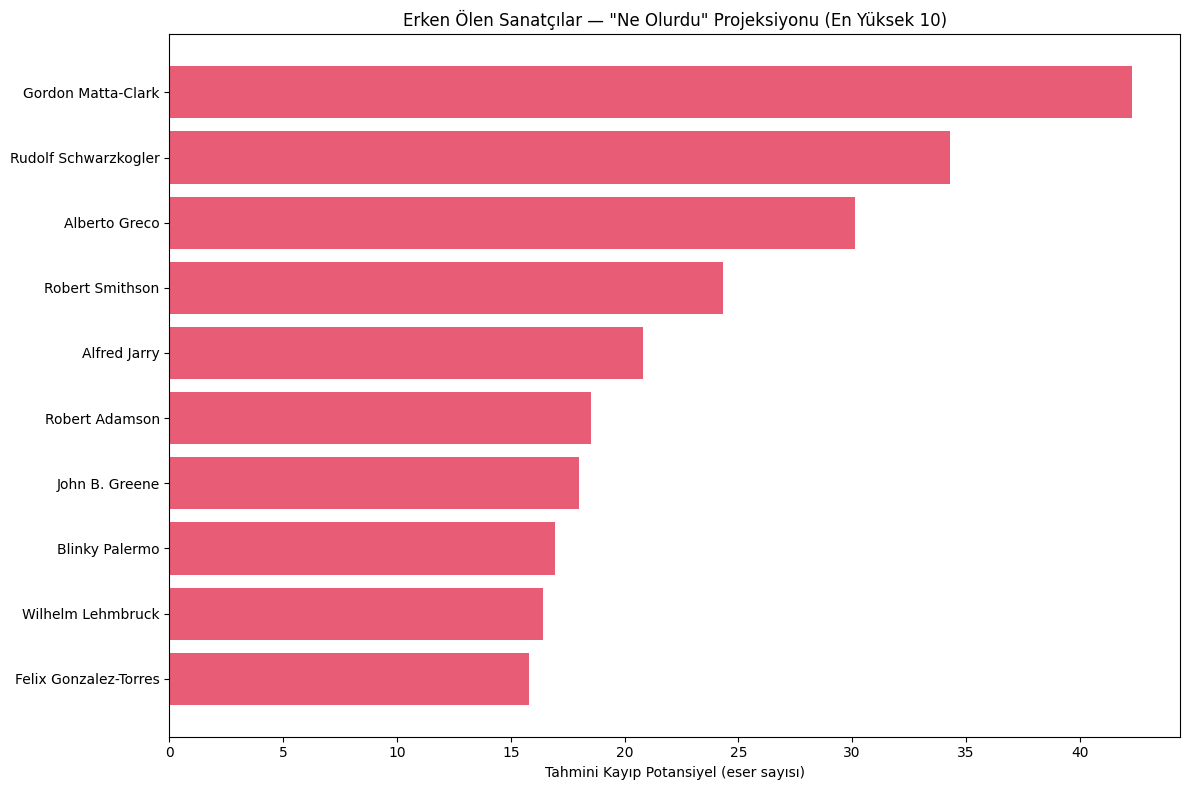

In [65]:
top10_unrealized = top_unrealized.head(10)

plt.figure(figsize=(12, 8))
plt.barh(top10_unrealized["DisplayName"], top10_unrealized["unrealized_potential"],
         color=FEMALE_C)
plt.xlabel("Estimated unrealized works")
plt.title('Artists Who Died Young — "What If" Projection (top 10)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Supplementary model — result and limits

`log(total + 1) = 1.057 × log(early_8yr + 1) + 0.182`, held-out **R² = 0.705**, n = 5,656.

Two out-of-sample checks: **Keith Haring** (actual 49, predicted 48.8) is near-exact;
**Basquiat** (actual 12, predicted 17) is over-predicted by 5, which is the direction an
early death should push it.

Across 187 artists who died young, the largest estimated gaps belong to **Gordon Matta-Clark**
(+42), **Robert Smithson** (+24) and **Felix Gonzalez-Torres** (+16) — figures art history
independently regards as major, which is a reassuring sign the model is picking up real
signal rather than noise.

> **This is the most speculative section of the project, and its limits are real.** R² = 0.705
> means roughly 30% of variance is unexplained. The model captures *one* thing — early
> productivity — and cannot see artistic development, changing reputation, market forces or
> MoMA's own shifting priorities. The output measures **presence in MoMA's collection**, not
> artistic output in the world. Read it as a structured thought experiment, not a forecast.

---

# 14. Serving layer — publishing results for BI

Analysis results are written back to `moma_dashboard` as flat, BI-friendly tables. This is
what separates a one-off notebook from a pipeline: the dashboard reads from BigQuery on a
schedule and never needs this notebook to have been run.

Two BigQuery constraints shape the export helper below. Column names may only contain letters,
digits and underscores — pivoted tables produce names like `Non-Western` — and a column name
may not start with a digit, which decade pivots produce by default (`1990`, `2000`).

> **Interface note.** Destination **table names** are deliberately unchanged from the original
> build, because they are what the BI dashboard binds to. The **column names inside them** are
> now English, so dashboard fields bound to the old column names need remapping once. That
> trade is taken on purpose: table names are the expensive thing to change, column labels are
> a one-time remap, and a serving layer nobody can read is worse than either.

In [ ]:
def bq_safe_columns(df):
    # BigQuery: identifiers are [A-Za-z0-9_] only and may not start with a digit.
    df = df.copy()
    df.columns = [re.sub(r"[^0-9a-zA-Z_]", "_", str(col)) for col in df.columns]
    df.columns = [f"y_{col}" if col[0].isdigit() else col for col in df.columns]
    return df


def publish(tables):
    for table_name, df in tables.items():
        pandas_gbq.to_gbq(bq_safe_columns(df),
                          destination_table=f"moma_dashboard.{table_name}",
                          project_id=PROJECT_ID, if_exists="replace")
        print(f"  published {table_name} — {df.shape}")


# NOTE: destination table names are intentionally unchanged from the original
# build. They are the contract the BI dashboard binds to; renaming them for
# internal consistency would break live reports.
print("Baseline lag tables:")
publish({
    "genel_gecikme_ozet_istatistik": (
        lag_computable["acquisition_lag"].describe()
        .to_frame().reset_index().set_axis(["statistic", "value"], axis=1)
    ),
    "genel_gecikme_on_yillik_trend": decade_summary,
    "genel_gecikme_histogram": (
        lambda counts, edges: pd.DataFrame({
            "bin_start": edges[:-1], "bin_end": edges[1:], "artwork_count": counts})
    )(*np.histogram(lag_computable["acquisition_lag"], bins=50)),
})

print("\nH1 (gender) tables:")
publish({
    "h1_genel_dagilim": gender_counts.reset_index().set_axis(
        ["gender_category", "artwork_rows"], axis=1),
    "h1_yapim_on_yillik": gender_by_creation_pct.reset_index(),
    "h1_edinim_on_yillik": gender_by_acq_pct.reset_index(),
    "h1_donemsel": pd.concat(
        [df.assign(period=p) for p, df in h1_periods.items()]).reset_index(),
    "h1_ham_gecikme": binary.groupby("gender_category")["acquisition_lag"]
        .agg(mean="mean", median="median", n="count").reset_index(),
    "h1_ham_uretim_yili": binary.groupby("gender_category")["extracted_year"]
        .agg(mean="mean", median="median").reset_index(),
    "h1_mannwhitney": h1_tests,
})

print("\nH2 (geography) tables:")
publish({
    "h2_top_ulkeler": top_countries.reset_index().set_axis(["country", "artwork_rows"], axis=1),
    "h2_genel_dagilim": geography_analysis["west_category"].value_counts()
        .reset_index().set_axis(["west_category", "artwork_rows"], axis=1),
    "h2_yapim_on_yillik": west_by_creation_pct.reset_index(),
    "h2_edinim_on_yillik": west_by_acq_pct.reset_index(),
    "h2_donemsel": pd.concat(
        [df.assign(period=p) for p, df in h2_periods.items()]).reset_index(),
    "h2_ham_gecikme": binary_geo.groupby("west_category")["acquisition_lag"]
        .agg(mean="mean", median="median", n="count").reset_index(),
    "h2_ham_uretim_yili": binary_geo.groupby("west_category")["extracted_year"]
        .agg(mean="mean", median="median").reset_index(),
    "h2_mannwhitney": h2_tests,
})

print("\nH3 (movement) tables:")
publish({
    "h3_genel_dagilim": pd.DataFrame({
        "movement": top10_movements.index, "artworks": top10_movements.values,
        "pct_of_tagged": pct_of_known.values, "pct_of_collection": pct_of_total.values}),
    "h3_uretim_pivot": creation_pivot.reset_index(),
    "h3_edinim_pivot": acquisition_pivot.reset_index(),
    "h3_sapma_analizi": movement_lag_trend.reset_index(),
    "h3_donemsel_korelasyon": h3_correlations,
})

print("\nH4 and supplementary model tables:")
publish({
    "h4_otokorelasyon_veri": h4_data[["acquisition_decade", "mean", "prev_decade_mean"]],
    "h4_otokorelasyon_test_sonucu": pd.DataFrame([{
        "r_value": r_h4, "p_value": p_h4, "n_observations": len(h4_clean),
        "significant": p_h4 < 0.05}]),
    "h4_gecikme_projeksiyonu_2100": h4_projection,
    "erken_olen_sanatci_projeksiyon": early_death[[
        "DisplayName", "BeginDate", "EndDate", "career_span", "early_artworks",
        "total_artworks", "predicted_total", "unrealized_potential"
    ]].sort_values("unrealized_potential", ascending=False).reset_index(drop=True),
    "erken_olen_model_dogrulama": model_validation,
    "erken_olen_model_ozet": pd.DataFrame([{
        "window_years": FINAL_WINDOW, "transform": "log1p",
        "slope": final_model.coef_[0], "intercept": final_model.intercept_,
        "r2_score": final_r2, "training_artists": len(final_data),
        "early_death_artists": len(early_death)}]),
})

print("\nServing layer refreshed.")

---

# 15. Conclusions

## The four hypotheses

**H1 — Gender: a real gap that closed.** Works by women created in 1950–70 waited a median
of 39 years against 11 for men — a 28-year gap, highly significant. It narrows to 9 years in
1970–90 and to zero in 1990–2010, where it is no longer statistically detectable
(*p* = 0.418). Representation rose from 16.2% (1970) to 40.3% (2020).

**H2 — Geography: a real gap that persists.** Non-Western works waited 2–3× longer in every
period. The gap narrows from 28 years to 5 but stays significant throughout (*p* < 0.001).

**H3 — Movements: a reversal.** Before 1970 MoMA collected most heavily where it had been an
early adopter (*r* = −0.64). After 2000 that inverts (*r* = +0.73) — it now collects most
heavily where it was late. The pooled correlation is *not* significant, because the two
opposite effects cancel; the era split is what reveals the structure.

**H4 — Temporal consistency: strong.** Lag-1 autocorrelation *r* = 0.855, *p* = 0.0016.
Behaviour evolves gradually and predictably, converging toward an equilibrium mean lag of
about 45 years.

## Answering the title question

**Both, in sequence.** In its founding decades MoMA behaved like a trend-setter, collecting
most heavily where it had moved first. Since 2000 it has behaved like a follower and a
corrector — buying into movements it once passed over, while the average work it acquires is
older each decade. The institution that once defined what modern art was now largely ratifies
what has already been decided elsewhere.

## The finding worth carrying out of this

Two disparities, one institution, one metric, one method — and only one of them closed.

The gender gap in acquisition *speed* is statistically gone. The geographic gap, measured
identically over the same seventy years, is not. That contrast is what makes it a finding
rather than an observation: MoMA has demonstrated that it can change this behaviour. The
persistence of the geographic gap is therefore about what got prioritised, not about what was
possible.

And on volume, both remain far from parity — roughly 6:1 male (123,378 vs 21,828 works)
and 7:1 Western (127,205 vs 18,969) as of 2020 — with trend
extrapolation putting equalisation near the end of this century under assumptions that
themselves are weakening.

## Limitations

**Movement coverage.** Wikidata supplies movement data for 43.4% of the collection. Coverage
is not random — better-documented, more canonical artists are likelier to have a QID — so H3
describes the well-documented portion of the collection, not all of it.

**Date parsing.** `extracted_year` takes the first 4-digit year in a free-text field. For
"1930 (printed 1944)" this can capture the wrong one. 95 works (0.06%) produce negative lags
as a result; they are flagged in `mart_acquisition_lag` rather than deleted, so the size of
the known-bad set is visible.

**The West / non-West binary.** A blunt simplification of a contested concept, defined
explicitly in Section 8.1. It is fit for the institutional question asked here and should not
be read as a claim about individual identity.

**Gender categories.** 428 raw values consolidated to 5. The male/female comparison excludes
non-binary and unknown categories, which are too small for the statistical tests used.

**Acquisition ≠ recognition.** Acquisition lag measures when a work entered *this* collection.
An artist may have been widely recognised long before MoMA acted, or acquired early and never
exhibited. The metric captures institutional behaviour, not artistic reputation.

**Projections are extrapolations.** Sections 12 and 13 assume current trends continue.
Policy, funding and leadership change; growth rates are already declining. Ranges are given
instead of point estimates wherever the underlying rate is unstable.

**Donation-driven composition.** Much of the collection arrived by bequest rather than
purchase. Some of what reads as curatorial choice is really the shape of what was offered —
the 1964 and 1968 spikes are the visible extreme of a pervasive effect.

---

## Further work

- Layer in exhibition data — acquisition and display are different forms of recognition
- Compare against a peer institution (the Met's open data is already structured for this)
- Model the acquisition-lag distribution directly (survival analysis fits the shape better
  than a mean comparison)
- Replace the West/non-West binary with a finer regional breakdown now that representation
  is large enough in more regions to support it

---

*Data: [MoMA Collection](https://github.com/MuseumofModernArt/collection) (CC0) ·
[Wikidata](https://www.wikidata.org) (CC0). dbt project:
[didemmrsln/moma_capstone](https://github.com/didemmrsln/moma_capstone).*